<a href="https://colab.research.google.com/github/ipm06tejasj-ctrl/Project1/blob/main/ITA_Project_IPM06196.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — Install required packages
# ─────────────────────────────────────────────────────────────────────────────
!pip install plotly kaleido --quiet
print('✅ Packages ready!')
!pip install streamlit --quiet
!npm install -g localtunnel --silent
print("✅ Done!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 3.8 MB/s eta 0:00:00
✅ Packages ready!
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 111.3 MB/s eta 0:00:00
✅ Done!


In [ ]:
%%writefile app.py
import subprocess, sys

# Auto-install all required packages
subprocess.run([sys.executable, "-m", "pip", "install",
                "feedparser", "vaderSentiment", "textblob",
                "plotly", "openpyxl", "--quiet"], check=True)

import streamlit as st
import streamlit.components.v1 as components
import pandas as pd
import numpy as np
import feedparser, time, re
from bs4 import BeautifulSoup
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import ComplementNB
from sklearn.pipeline import Pipeline
from datetime import datetime, timedelta
import plotly.graph_objects as go
import plotly.express as px

st.set_page_config(page_title="QuantSentinel", page_icon="📡", layout="wide")

vader = SentimentIntensityAnalyzer()

TRAIN = [
    ('record earnings beat profit surge stock rises rally investors cheer','Positive'),
    ('strong jobs gdp growth beats forecast economy resilient consumer up','Positive'),
    ('fed pause dovish signals rate cut expected bond yields drop markets','Positive'),
    ('drug approval fda breakthrough biotech stock jumps gains soar','Positive'),
    ('tech revenue smashes forecast shares surge ai chip demand record','Positive'),
    ('merger deal approved synergies shareholders dividend raised buyback','Positive'),
    ('inflation cools lower unemployment falls hiring wages rise confident','Positive'),
    ('s&p 500 record high dow jones rally nasdaq gains technology leads','Positive'),
    ('recession fears grow gdp contraction jobless claims spike rises','Negative'),
    ('inflation surges rate hike aggressive sell off markets plunge crash','Negative'),
    ('earnings miss guidance cut revenue declines profit falls stocks drop','Negative'),
    ('bank collapse scandal stock crashes crisis contagion fear panic','Negative'),
    ('geopolitical tension war sanctions oil shock markets tumble selling','Negative'),
    ('trade war tariff escalation export decline slump recession risk','Negative'),
    ('fed hike aggressive hawkish tightening growth stocks hit pressure','Negative'),
    ('central bank holds steady rates unchanged policy expected forecast','Neutral'),
    ('earnings season begins analysts await results guidance mixed signals','Neutral'),
    ('market mixed consolidates range investors cautious await data thin','Neutral'),
    ('fed minutes divided policymakers split decision calendar light quiet','Neutral'),
    ('commodity stable range bound supply demand balanced investors wait','Neutral'),
]

nb_model = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2), min_df=1,
                               sublinear_tf=True, stop_words='english')),
    ('clf',   ComplementNB(alpha=0.3))
])
nb_model.fit([t for t,_ in TRAIN], [l for _,l in TRAIN])

FIN_KW = ['stock','market','share','invest','profit','loss','revenue','gdp',
          'inflation','rate','bond','yield','fed','bank','economy','financial',
          'price','growth','recession','rally','crash','surge','plunge','gain',
          'decline','earnings','merger','dividend','nasdaq','dow','oil','gold',
          'dollar','crypto','bitcoin','tariff','acquisition','ipo','buyback']

SECTORS = {
    'Technology':   ['tech','software','ai','chip','cloud','apple','microsoft','nvidia','google','meta','amazon'],
    'Finance':      ['bank','financial','fed','rate','bond','credit','mortgage','interest','goldman','jpmorgan'],
    'Energy':       ['oil','gas','energy','crude','opec','solar','renewable','exxon','chevron'],
    'Healthcare':   ['health','pharma','drug','fda','biotech','vaccine','pfizer','johnson','merck'],
    'Consumer':     ['retail','consumer','spending','sales','walmart','target','luxury','food'],
    'Macro/Global': ['gdp','inflation','recession','unemployment','jobs','tariff','imf','fiscal'],
}

RSS_FEEDS = {
    'Reuters':         'https://feeds.reuters.com/reuters/businessNews',
    'Yahoo Finance':   'https://finance.yahoo.com/news/rssindex',
    'CNBC':            'https://www.cnbc.com/id/10000664/device/rss/rss.html',
    'MarketWatch':     'https://feeds.content.dowjones.io/public/rss/mw_realtimeheadlines',
    'FT':              'https://www.ft.com/rss/home/uk',
    'Bloomberg':       'https://feeds.bloomberg.com/markets/news.rss',
    'WSJ':             'https://feeds.a.dj.com/rss/RSSMarketsMain.xml',
    'Investing.com':   'https://www.investing.com/rss/news.rss',
    'Seeking Alpha':   'https://seekingalpha.com/market_currents.xml',
    'Business Insider':'https://markets.businessinsider.com/rss/news',
}

SEEDS = [
    ('Reuters',       'Fed signals three rate cuts in 2025 markets surge on dovish pivot'),
    ('Bloomberg',     'Nvidia earnings smash estimates as AI chip demand breaks all records'),
    ('CNBC',          'Strong jobs report exceeds expectations Wall Street rallies sharply'),
    ('Yahoo Finance', 'Apple unveils AI product line shares surge 5 percent premarket'),
    ('Reuters',       'US economy enters recession unemployment jumps to 8 percent GDP falls'),
    ('Bloomberg',     'Banking sector faces regulatory scrutiny stocks tumble broadly'),
    ('CNBC',          'Tech layoffs continue NASDAQ drops more than 2 percent growth stocks'),
    ('Reuters',       'Inflation cools further bond yields drop sharply investors cheer'),
    ('FT',            'Merger approved pharmaceutical giants create new global industry leader'),
    ('Bloomberg',     'IMF cuts global growth forecast citing persistent inflation risks'),
    ('Reuters',       'Central bank holds rates steady as expected by most economists'),
    ('CNBC',          'Market volumes remain thin ahead of holiday-shortened trading week'),
    ('Yahoo Finance', 'Sector rotation observed as investors reassess valuations broadly'),
    ('Reuters',       'Healthcare stocks soar after FDA breakthrough drug approval announced'),
    ('Bloomberg',     'Oil prices crash as OPEC fails to agree on production cuts supply'),
    ('WSJ',           'Consumer confidence rises to post-pandemic high retail sales beat'),
    ('FT',            'Trade war escalates new tariffs hit export-dependent sectors hard'),
    ('Reuters',       'Solar energy investment hits record high green transition accelerating'),
    ('Bloomberg',     'Mortgage rates hit 23-year high housing market cools sharply'),
    ('CNBC',          'Tesla deliveries beat estimates shares up 8 percent in premarket'),
]

def clean_text(t):
    if not isinstance(t, str): return ''
    t = BeautifulSoup(t, 'html.parser').get_text()
    t = re.sub(r'http\S+', '', t)
    t = re.sub(r'[^a-zA-Z0-9\s\'\-\%\$\.\,]', ' ', t)
    return re.sub(r'\s+', ' ', t).strip()

def detect_sector(t):
    tl = t.lower()
    sc = {s: sum(1 for kw in kws if kw in tl) for s, kws in SECTORS.items()}
    best = max(sc, key=sc.get)
    return best if sc[best] > 0 else 'General'

def detect_region(t):
    tl = t.lower()
    if any(w in tl for w in ['us ','u.s','america','wall street','nasdaq','dow','fed']): return 'USA'
    if any(w in tl for w in ['europe','eu ','ecb','euro','uk ','britain']): return 'Europe'
    if any(w in tl for w in ['china','japan','asia','india','yuan','yen']): return 'Asia'
    return 'Global'

def count_kw(t): return sum(1 for kw in FIN_KW if kw in t.lower())

def analyze(hl):
    vc    = vader.polarity_scores(hl)
    nb_p  = nb_model.predict([hl])[0]
    probs = dict(zip(nb_model.classes_, nb_model.predict_proba([hl])[0]))
    v_lbl = 'Positive' if vc['compound']>=0.05 else ('Negative' if vc['compound']<=-0.05 else 'Neutral')
    final = nb_p if nb_p==v_lbl else v_lbl
    return {
        'sentiment': final, 'vader': round(vc['compound'],4),
        'nb_pos': round(probs.get('Positive',0),4),
        'nb_neg': round(probs.get('Negative',0),4),
        'confidence': 'High' if nb_p==v_lbl else 'Medium'
    }

def sector_score(sub_df):
    if len(sub_df)==0: return 50.0
    avg = sub_df['VADER_Score'].mean()
    pos = (sub_df['Sentiment']=='Positive').mean()
    neg = (sub_df['Sentiment']=='Negative').mean()
    nb  = (sub_df['NB_Conf']=='High').mean()
    return round(min(max(
        (avg+1)/2*40 + pos*25 + (1-neg)*15 + nb*10 + min(len(sub_df)/15,1)*10,
        0), 100), 1)

def rec_label(score):
    if score>=70: return 'STRONG BUY'
    if score>=58: return 'BUY'
    if score>=45: return 'HOLD'
    if score>=32: return 'WATCH'
    return 'SELL/AVOID'

def rec_emoji(rec):
    return {'STRONG BUY':'🟢','BUY':'🟢','HOLD':'🟡','WATCH':'🔵','SELL/AVOID':'🔴'}.get(rec,'⚪')

# ─────────────────────────────────────────────────────────────────────────────
# CSS
# ─────────────────────────────────────────────────────────────────────────────
st.markdown("""
<style>
  [data-testid="stAppViewContainer"]{background:#0a0f1e}
  [data-testid="stSidebar"]{background:#111827}
  .stTabs [data-baseweb="tab-list"]{background:#111827;border-radius:8px;padding:4px}
  .stTabs [data-baseweb="tab"]{color:#94a3b8}
  .stTabs [aria-selected="true"]{background:#1a2234;border-radius:6px;color:#e2e8f0}
  .metric-card{background:#111827;border:1px solid #1e2d45;border-radius:10px;
               padding:20px;text-align:center;margin-bottom:8px}
  .big-signal{font-size:52px;font-weight:900;line-height:1;margin:8px 0}
  .sig-buy{color:#00e5a0} .sig-sell{color:#ff4757} .sig-hold{color:#ffc542}
  .hl-card{background:#111827;border-radius:6px;padding:12px 16px;
           margin-bottom:8px;border-left:4px solid #1e2d45}
  .hl-pos{border-left-color:#00e5a0}
  .hl-neg{border-left-color:#ff4757}
  .hl-neu{border-left-color:#334155}
  .tag{display:inline-block;background:#1a2234;color:#64748b;font-size:10px;
       padding:2px 8px;border-radius:3px;margin-right:4px;margin-top:4px}
  div[data-testid="metric-container"]{background:#111827;border:1px solid #1e2d45;
       border-radius:10px;padding:12px 16px}
  div[data-testid="metric-container"] label{color:#64748b !important}
  div[data-testid="metric-container"] div{color:#e2e8f0 !important}
</style>
""", unsafe_allow_html=True)

# ─────────────────────────────────────────────────────────────────────────────
# SIDEBAR
# ─────────────────────────────────────────────────────────────────────────────
st.sidebar.markdown("## 📡 QuantSentinel")
st.sidebar.markdown("*AI-Powered Investor Engine*")
st.sidebar.divider()
run_scrape   = st.sidebar.button("🔄 Refresh Live News", use_container_width=True)
max_articles = st.sidebar.slider("Articles per source", 5, 40, 15)
st.sidebar.divider()
st.sidebar.markdown("**Data Sources**")
for src in RSS_FEEDS.keys():
    st.sidebar.markdown(f"• {src}")

# ─────────────────────────────────────────────────────────────────────────────
# SCRAPE & PROCESS
# ─────────────────────────────────────────────────────────────────────────────
if 'df' not in st.session_state or run_scrape:
    with st.spinner("🌐 Scraping live financial news from 10 sources..."):
        raw = []
        progress = st.progress(0)
        for i, (name, url) in enumerate(RSS_FEEDS.items()):
            try:
                feed = feedparser.parse(url, request_headers={'User-Agent':'academic-bot/1.0'})
                for e in feed.entries[:max_articles]:
                    t = clean_text(e.get('title',''))
                    if len(t)>20 and any(kw in t.lower() for kw in FIN_KW):
                        raw.append({'Source':name, 'Headline':t,
                                    'Published':e.get('published','')})
            except: pass
            progress.progress((i+1)/len(RSS_FEEDS))
            time.sleep(0.2)
        progress.empty()

        if len(raw) < 15:
            st.warning(f"⚠️ Only {len(raw)} articles scraped live. Using seed data to supplement.")
            for src, hl in SEEDS:
                raw.append({'Source':src,'Headline':hl,'Published':datetime.today().strftime('%a, %d %b %Y')})

        rows = []
        for r in raw:
            hl  = r['Headline']
            nlp = analyze(hl)
            rows.append({
                'Source':       r['Source'],
                'Headline':     hl,
                'Sector':       detect_sector(hl),
                'Region':       detect_region(hl),
                'Sentiment':    nlp['sentiment'],
                'VADER_Score':  nlp['vader'],
                'NB_Pos':       nlp['nb_pos'],
                'NB_Neg':       nlp['nb_neg'],
                'NB_Conf':      nlp['confidence'],
                'Keyword_Count':count_kw(hl),
            })

        df = pd.DataFrame(rows).drop_duplicates('Headline').reset_index(drop=True)
        st.session_state.df = df
        st.session_state.scraped_at = datetime.now().strftime('%H:%M:%S')
        st.success(f"✅ {len(df)} articles loaded from {df['Source'].nunique()} sources")

df = st.session_state.df
scraped_at = st.session_state.get('scraped_at', 'cached')

# ─────────────────────────────────────────────────────────────────────────────
# COMPUTE SIGNALS
# ─────────────────────────────────────────────────────────────────────────────
overall   = float(df['VADER_Score'].mean())
pos_pct   = float((df['Sentiment']=='Positive').mean()*100)
neg_pct   = float((df['Sentiment']=='Negative').mean()*100)
neu_pct   = 100 - pos_pct - neg_pct
momentum  = float(df['VADER_Score'].tail(min(20,len(df))).mean() - overall)
sent_std  = float(df['VADER_Score'].std())
composite = overall*30 + momentum*20 + (pos_pct-neg_pct)/100*15

if   composite >  8: action,sig,risk = 'BUY',  'Bullish — Positive news dominates',       'LOW-MEDIUM'
elif composite >  2: action,sig,risk = 'BUY',  'Mildly bullish — Watch for confirmation', 'MEDIUM'
elif composite < -8: action,sig,risk = 'SELL', 'Bearish — Negative news dominates',       'HIGH'
elif composite < -2: action,sig,risk = 'SELL', 'Mildly bearish — Reduce exposure',        'MEDIUM-HIGH'
else:                action,sig,risk = 'HOLD', 'Neutral — Mixed signals, await clarity',  'MEDIUM'

vol_lvl = 'High' if sent_std>0.35 else ('Medium' if sent_std>0.20 else 'Low')

# Weekend effect
we_ret  = round(overall*0.85 - 0.10, 3)
we_sig  = 'BUY' if we_ret>0.06 else ('SELL' if we_ret<-0.06 else 'HOLD')

# ─────────────────────────────────────────────────────────────────────────────
# HEADER
# ─────────────────────────────────────────────────────────────────────────────
st.markdown(f"""
<div style='display:flex;justify-content:space-between;align-items:center;
            border-bottom:1px solid #1e2d45;padding-bottom:16px;margin-bottom:20px'>
  <div>
    <h1 style='margin:0;font-size:28px;color:#e2e8f0'>
      📡 Quant<span style='color:#00e5a0'>Sentinel</span>
    </h1>
    <p style='margin:4px 0 0;color:#64748b;font-size:13px'>
      AI-Powered Investor Decision Engine · IPM06196
    </p>
  </div>
  <div style='text-align:right;font-size:12px;color:#64748b'>
    {len(df)} articles · {df['Source'].nunique()} sources<br>
    Last updated: {scraped_at}
  </div>
</div>
""", unsafe_allow_html=True)

# ─────────────────────────────────────────────────────────────────────────────
# TOP METRICS ROW
# ─────────────────────────────────────────────────────────────────────────────
m1, m2, m3, m4, m5, m6 = st.columns(6)
signal_color = '#00e5a0' if action=='BUY' else '#ff4757' if action=='SELL' else '#ffc542'

with m1:
    st.markdown(f"""
    <div class='metric-card'>
      <div style='font-size:10px;color:#64748b;letter-spacing:1px;text-transform:uppercase'>Signal</div>
      <div class='big-signal' style='color:{signal_color}'>{action}</div>
    </div>""", unsafe_allow_html=True)
with m2:
    delta2 = f"{pos_pct-50:+.1f}% vs 50"
    st.metric("🟢 Positive", f"{pos_pct:.1f}%", delta2)
with m3:
    st.metric("🔴 Negative", f"{neg_pct:.1f}%", f"{neg_pct-30:+.1f}% vs avg", delta_color="inverse")
with m4:
    st.metric("⚡ Composite", f"{composite:+.2f}")
with m5:
    st.metric("📊 Volatility", vol_lvl)
with m6:
    st.metric("📰 Articles", len(df))

color_map = {'LOW-MEDIUM':'#00e5a0','MEDIUM':'#ffc542','MEDIUM-HIGH':'#ff8c42','HIGH':'#ff4757'}
st.markdown(f"""
<div style='background:#111827;border:1px solid #1e2d45;border-radius:8px;
            padding:14px 20px;margin:12px 0;display:flex;gap:20px;align-items:center'>
  <span style='font-size:13px;color:#e2e8f0'>📢 <b>{sig}</b></span>
  <span style='background:{color_map.get(risk,"#ffc542")}22;color:{color_map.get(risk,"#ffc542")};
               padding:3px 10px;border-radius:3px;font-size:11px;font-weight:700'>
    RISK: {risk}
  </span>
  <span style='color:#64748b;font-size:11px'>Momentum: {momentum:+.4f}</span>
</div>
""", unsafe_allow_html=True)

st.divider()

# ─────────────────────────────────────────────────────────────────────────────
# TABS
# ─────────────────────────────────────────────────────────────────────────────
tab1, tab2, tab3, tab4, tab5 = st.tabs([
    "🏭 Sector Heatmap",
    "📅 Day Predictions",
    "💼 Investor Predictor",
    "📰 News Feed",
    "📊 Charts"
])

# ── TAB 1: Sector Heatmap ─────────────────────────────────────────────────────
with tab1:
    st.subheader("🏭 Sector Investability Scores")
    st.caption("Score 0–100 based on sentiment, positivity rate, NB confidence, and news volume")

    sector_rows = []
    for sector in df['Sector'].unique():
        sub   = df[df['Sector']==sector]
        score = sector_score(sub)
        rec   = rec_label(score)
        sector_rows.append({
            'Sector':        sector,
            'Score':         score,
            'Recommendation':rec_emoji(rec)+' '+rec,
            'Avg Sentiment': round(float(sub['VADER_Score'].mean()),4),
            'Positive %':    round(float((sub['Sentiment']=='Positive').mean()*100),1),
            'Negative %':    round(float((sub['Sentiment']=='Negative').mean()*100),1),
            'Articles':      len(sub),
        })

    sec_df = pd.DataFrame(sector_rows).sort_values('Score', ascending=False)

    st.dataframe(
        sec_df,
        use_container_width=True,
        hide_index=True,
        column_config={
            'Score': st.column_config.ProgressColumn(
                'Score', min_value=0, max_value=100, format='%d / 100'),
            'Avg Sentiment': st.column_config.NumberColumn(format='%+.4f'),
            'Positive %':    st.column_config.NumberColumn(format='%.1f%%'),
            'Negative %':    st.column_config.NumberColumn(format='%.1f%%'),
        }
    )

    col_a, col_b = st.columns(2)
    with col_a:
        fig_score = go.Figure(go.Bar(
            x=sec_df['Score'],
            y=sec_df['Sector'],
            orientation='h',
            marker=dict(
                color=sec_df['Score'],
                colorscale=[[0,'#ff4757'],[0.4,'#ffc542'],[0.7,'#55efc4'],[1,'#00e5a0']],
                cmin=0, cmax=100
            ),
            text=sec_df['Score'].astype(int).astype(str)+'/100',
            textposition='outside'
        ))
        fig_score.update_layout(
            title='Investability Score by Sector',
            plot_bgcolor='#111827', paper_bgcolor='#111827',
            font_color='#e2e8f0', height=350,
            xaxis=dict(range=[0,115], gridcolor='#1e2d45'),
            yaxis=dict(gridcolor='#1e2d45'),
            margin=dict(l=10,r=10,t=40,b=10)
        )
        st.plotly_chart(fig_score, use_container_width=True)

    with col_b:
        fig_sent = go.Figure()
        for sent, color in [('Positive','#00e5a0'),('Neutral','#334155'),('Negative','#ff4757')]:
            vals = [round(float((df[df['Sector']==s]['Sentiment']==sent).mean()*100),1)
                    for s in sec_df['Sector']]
            fig_sent.add_bar(name=sent, x=sec_df['Sector'].tolist(),
                              y=vals, marker_color=color)
        fig_sent.update_layout(
            barmode='stack', title='Sentiment Breakdown by Sector',
            plot_bgcolor='#111827', paper_bgcolor='#111827',
            font_color='#e2e8f0', height=350,
            legend=dict(bgcolor='#111827'),
            margin=dict(l=10,r=10,t=40,b=10)
        )
        st.plotly_chart(fig_sent, use_container_width=True)

# ── TAB 2: Day Predictions ────────────────────────────────────────────────────
with tab2:
    st.subheader("📅 Day-to-Day Market Predictions")
    st.caption("Each day's news → next trading day's expected return")

    DAY_BIAS = {'Monday':-0.10,'Tuesday':+0.08,'Wednesday':+0.12,'Thursday':+0.06,'Friday':+0.04}
    NEXT_DAY = {'Monday':'Tuesday','Tuesday':'Wednesday','Wednesday':'Thursday',
                'Thursday':'Friday','Friday':'Monday'}

    weights   = df['Keyword_Count'].clip(1).values
    base_sent = float(np.average(df['VADER_Score'].values, weights=weights))
    roll_avg  = float(df['VADER_Score'].mean())
    momentum2 = base_sent - roll_avg

    day_rows = []
    for day in ['Monday','Tuesday','Wednesday','Thursday','Friday']:
        tomorrow = NEXT_DAY[day]
        bias     = DAY_BIAS.get(tomorrow, 0)
        exp      = round(base_sent*0.65 + momentum2*0.25 + bias, 3)
        if   exp> 0.35: sig2,act2 = 'STRONG BUY','BUY'
        elif exp> 0.06: sig2,act2 = 'BUY','BUY'
        elif exp<-0.35: sig2,act2 = 'STRONG SELL','SELL'
        elif exp<-0.06: sig2,act2 = 'SELL','SELL'
        else:           sig2,act2 = 'HOLD','HOLD'
        conf = round(60 + (df['NB_Conf']=='High').mean()*30, 1)
        day_rows.append({'Today':day,'Tomorrow':tomorrow,
                          'Expected Return %':exp,'Signal':sig2,
                          'Action':act2,'Confidence %':conf})

    day_df = pd.DataFrame(day_rows)
    st.dataframe(day_df, use_container_width=True, hide_index=True,
                  column_config={'Expected Return %':st.column_config.NumberColumn(format='%+.3f%%'),
                                  'Confidence %':st.column_config.NumberColumn(format='%.1f%%')})

    fig_day = px.bar(
        day_df, x='Today', y='Expected Return %',
        color='Expected Return %',
        color_continuous_scale=['#ff4757','#ffc542','#00e5a0'],
        text=day_df['Expected Return %'].apply(lambda v: f'{v:+.3f}%'),
        title='Expected Next-Day Return per News Day'
    )
    fig_day.update_traces(textposition='outside')
    fig_day.update_layout(
        plot_bgcolor='#111827', paper_bgcolor='#111827',
        font_color='#e2e8f0', height=320,
        margin=dict(t=40,b=10), coloraxis_showscale=False
    )
    fig_day.add_hline(y=0, line_color='#334155', line_dash='dash')
    st.plotly_chart(fig_day, use_container_width=True)

    st.subheader("📅 Weekend Effect → Monday Opening")
    wc1, wc2, wc3, wc4 = st.columns(4)
    wc1.metric("Weekend Articles",  str(max(1, len(df[df['Keyword_Count']>3]))))
    wc2.metric("Overall Sentiment", f"{overall:+.4f}")
    wc3.metric("Expected Monday",   f"{we_ret:+.3f}%")
    wc4.metric("Signal",            we_sig)

# ── TAB 3: Predictor ──────────────────────────────────────────────────────────
with tab3:
    st.subheader("💼 Investor Prediction Engine")
    st.caption("Enter any financial headline → get BUY / HOLD / SELL with full reasoning")

    hl_input  = st.text_area("📰 Paste any financial headline:",
                               placeholder="e.g.  Fed cuts rates by 50bps as inflation hits target...")
    day_input = st.selectbox("📆 Day of publication:",
                               ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

    if st.button("▶  Predict Market Reaction", use_container_width=True, type='primary'):
        if hl_input.strip():
            nlp2   = analyze(hl_input.strip())
            sec2   = detect_sector(hl_input)
            sub2   = df[df['Sector']==sec2]
            sc2    = sector_score(sub2)
            rc2    = rec_label(sc2)

            if   nlp2['sentiment']=='Positive' and nlp2['vader']>0.08 and sc2>=55:
                inv_action = 'BUY'
                reason = f"Strong positive sentiment (VADER={nlp2['vader']:+.3f}). Sector '{sec2}' is investable (Score={sc2:.0f}/100, {rc2}). Consider entering a position."
            elif nlp2['sentiment']=='Negative' and nlp2['vader']<-0.08:
                inv_action = 'SELL / AVOID'
                reason = f"Negative sentiment detected (VADER={nlp2['vader']:+.3f}). Bearish signals in '{sec2}' sector (Score={sc2:.0f}/100). Reduce or avoid exposure."
            elif nlp2['sentiment']=='Positive' and sc2<45:
                inv_action = 'WATCH'
                reason = f"Positive headline but '{sec2}' sector overall weak (Score={sc2:.0f}/100, {rc2}). Wait for sector-wide confirmation before entering."
            else:
                inv_action = 'HOLD'
                reason = f"Mixed signals on '{sec2}' (Score={sc2:.0f}/100, {rc2}). No strong directional trade. Monitor and await clarity."

            action_colors = {'BUY':'#00e5a0','SELL / AVOID':'#ff4757','WATCH':'#3d9bff','HOLD':'#ffc542'}
            acolor = action_colors.get(inv_action,'#ffc542')

            st.markdown(f"""
            <div style='background:#111827;border:1px solid {acolor}40;border-radius:10px;
                        padding:20px;margin-top:12px'>
              <div style='font-size:42px;font-weight:900;color:{acolor};line-height:1'>{inv_action}</div>
              <div style='margin-top:10px;color:#94a3b8;font-size:13px;line-height:1.6'>{reason}</div>
            </div>
            """, unsafe_allow_html=True)

            r1,r2,r3,r4 = st.columns(4)
            r1.metric("Sentiment",    nlp2['sentiment'])
            r2.metric("VADER Score",  f"{nlp2['vader']:+.4f}")
            r3.metric("Sector",       sec2)
            r4.metric("Sector Score", f"{sc2:.0f}/100")

            prob_col1, prob_col2, prob_col3 = st.columns(3)
            prob_col1.metric("P(Positive)", f"{nlp2['nb_pos']:.3f}")
            prob_col2.metric("P(Negative)", f"{nlp2['nb_neg']:.3f}")
            prob_col3.metric("NB Confidence", nlp2['confidence'])
        else:
            st.warning("⚠️ Please enter a headline first.")

    st.divider()
    st.markdown("**🧪 Quick test examples — click to try:**")
    examples = [
        "Fed signals three rate cuts in 2025 markets surge on dovish pivot",
        "Nvidia earnings smash estimates as AI chip demand breaks all records",
        "US economy enters recession unemployment jumps sharply GDP contracts",
        "Bitcoin crashes 30 percent as regulators announce strict crypto rules",
        "Pfizer announces breakthrough cancer drug FDA fast-track approval",
        "Trade war escalates new tariffs hit export-dependent sectors hard",
    ]
    cols = st.columns(2)
    for i, ex in enumerate(examples):
        with cols[i%2]:
            if st.button(f"→ {ex[:55]}...", key=f"ex_{i}"):
                nlp_q  = analyze(ex)
                sec_q  = detect_sector(ex)
                sc_q   = sector_score(df[df['Sector']==sec_q])
                action_colors2 = {'Positive':'🟢 BUY','Negative':'🔴 SELL','Neutral':'🟡 HOLD'}
                st.write(f"**{action_colors2.get(nlp_q['sentiment'],'⚪')}** | "
                         f"VADER: `{nlp_q['vader']:+.4f}` | "
                         f"Sector: {sec_q} ({sc_q:.0f}/100)")

# ── TAB 4: News Feed ──────────────────────────────────────────────────────────
with tab4:
    st.subheader("📰 Live News Feed")

    f1, f2, f3 = st.columns([2,2,1])
    with f1:
        filter_sent = st.selectbox("Filter by Sentiment:", ['All','Positive','Negative','Neutral'])
    with f2:
        filter_sec  = st.selectbox("Filter by Sector:", ['All'] + sorted(df['Sector'].unique().tolist()))
    with f3:
        sort_by     = st.selectbox("Sort by:", ['VADER Score','Keyword Count'])

    feed_df = df.copy()
    if filter_sent != 'All': feed_df = feed_df[feed_df['Sentiment']==filter_sent]
    if filter_sec  != 'All': feed_df = feed_df[feed_df['Sector']==filter_sec]

    sort_col = 'VADER_Score' if sort_by=='VADER Score' else 'Keyword_Count'
    feed_df  = feed_df.reindex(feed_df[sort_col].abs().sort_values(ascending=False).index)

    st.caption(f"Showing {len(feed_df)} articles")

    for _, row in feed_df.iterrows():
        bc    = '#00e5a0' if row['Sentiment']=='Positive' else '#ff4757' if row['Sentiment']=='Negative' else '#334155'
        em    = '🟢' if row['Sentiment']=='Positive' else '🔴' if row['Sentiment']=='Negative' else '🟡'
        vc    = row['VADER_Score']
        vc_c  = '#00e5a0' if vc>0 else '#ff4757'
        st.markdown(f"""
        <div style='background:#111827;border-radius:6px;padding:12px 16px;
                    margin-bottom:8px;border-left:4px solid {bc}'>
          <div style='font-size:13px;color:#e2e8f0;line-height:1.5'>{em} {row['Headline']}</div>
          <div style='margin-top:6px'>
            <span class='tag'>{row['Source']}</span>
            <span class='tag'>{row['Sector']}</span>
            <span style='font-size:11px;color:{vc_c};background:{vc_c}20;
                         padding:2px 8px;border-radius:3px'>
              VADER {vc:+.4f}
            </span>
          </div>
        </div>""", unsafe_allow_html=True)

# ── TAB 5: Charts ─────────────────────────────────────────────────────────────
with tab5:
    st.subheader("📊 Sentiment Analytics")

    ca, cb = st.columns(2)
    with ca:
        fig_hist = go.Figure()
        for sent, color in [('Positive','#00e5a0'),('Neutral','#64748b'),('Negative','#ff4757')]:
            sub = df[df['Sentiment']==sent]['VADER_Score']
            if len(sub)>1:
                fig_hist.add_trace(go.Histogram(x=sub, name=sent, marker_color=color,
                                                 opacity=0.7, nbinsx=20))
        fig_hist.update_layout(barmode='overlay', title='VADER Score Distribution',
                                plot_bgcolor='#111827', paper_bgcolor='#111827',
                                font_color='#e2e8f0', height=320,
                                legend=dict(bgcolor='#111827'),
                                margin=dict(t=40,b=10))
        fig_hist.add_vline(x=0, line_color='#334155', line_dash='dash')
        st.plotly_chart(fig_hist, use_container_width=True)

    with cb:
        source_sent = df.groupby('Source')['VADER_Score'].mean().sort_values()
        fig_src = px.bar(source_sent, orientation='h',
                          color=source_sent.values,
                          color_continuous_scale=['#ff4757','#ffc542','#00e5a0'],
                          title='Avg Sentiment by Source')
        fig_src.update_layout(plot_bgcolor='#111827', paper_bgcolor='#111827',
                               font_color='#e2e8f0', height=320,
                               coloraxis_showscale=False,
                               margin=dict(t=40,b=10))
        st.plotly_chart(fig_src, use_container_width=True)

    fig_scatter = px.scatter(
        df, x='VADER_Score', y='Keyword_Count',
        color='Sentiment', size='NB_Pos',
        color_discrete_map={'Positive':'#00e5a0','Negative':'#ff4757','Neutral':'#64748b'},
        hover_data=['Headline','Source','Sector'],
        title='VADER Score vs Financial Keyword Count'
    )
    fig_scatter.update_layout(plot_bgcolor='#111827', paper_bgcolor='#111827',
                               font_color='#e2e8f0', height=380,
                               legend=dict(bgcolor='#111827'),
                               margin=dict(t=40,b=10))
    st.plotly_chart(fig_scatter, use_container_width=True)

# ── Footer ────────────────────────────────────────────────────────────────────
st.divider()
st.markdown("""
<div style='text-align:center;color:#334155;font-size:12px;padding:10px 0'>
  QuantSentinel · IPM06196 Tejas Jindal · Dr. Karan Verma ·
  K-Means + Decision Tree + Naïve Bayes + VADER
</div>""", unsafe_allow_html=True)

Overwriting app.py


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — Import all libraries
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Machine Learning ──────────────────────────────────────────────────────────
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.decomposition import PCA

# ── Reproducibility ───────────────────────────────────────────────────────────
np.random.seed(42)

print('✅ All libraries imported successfully!')
print('🔢 NumPy:', np.__version__, ' | 🐼 Pandas:', pd.__version__)

✅ All libraries imported successfully!
🔢 NumPy: 2.0.2  | 🐼 Pandas: 2.2.2


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — Synthetic Dataset Generation with Realistic Noise
# ─────────────────────────────────────────────────────────────────────────────

np.random.seed(42)
N = 500  # number of news articles

# ── Date range: Jan 2021 → Dec 2024 ──────────────────────────────────────────
dates = pd.date_range(start='2021-01-04', end='2024-12-31', freq='B')  # business days
dates = np.random.choice(dates, size=N, replace=True)
dates = pd.to_datetime(dates)

# ── Categorical variables ──────────────────────────────────────────────────────
sectors      = ['Technology', 'Finance', 'Energy', 'Healthcare', 'Consumer']
regions      = ['USA', 'Europe', 'Asia', 'Global']
sources      = ['Reuters', 'Bloomberg', 'CNBC', 'WSJ', 'Financial Times']
event_types  = ['Earnings', 'Merger', 'Policy Change', 'Economic Data', 'Geopolitical']
sent_labels  = ['Positive', 'Negative', 'Neutral']

sector_col    = np.random.choice(sectors,     size=N, p=[0.30, 0.25, 0.15, 0.15, 0.15])
region_col    = np.random.choice(regions,     size=N, p=[0.40, 0.25, 0.20, 0.15])
source_col    = np.random.choice(sources,     size=N)
event_col     = np.random.choice(event_types, size=N, p=[0.30, 0.15, 0.20, 0.20, 0.15])
sent_label_col = np.random.choice(sent_labels, size=N, p=[0.40, 0.35, 0.25])

# ── NLP-derived sentiment features ────────────────────────────────────────────
# Sentiment score: [-1, 1] correlated with label + noise
base_score = {'Positive': 0.45, 'Negative': -0.42, 'Neutral': 0.02}
sentiment_score = np.array([base_score[s] for s in sent_label_col])
sentiment_score += np.random.normal(0, 0.18, N)          # Gaussian noise
sentiment_score  = np.clip(sentiment_score, -1, 1)

subjectivity_score = np.random.beta(2.5, 3.5, N)         # 0–1, realistic distribution
headline_length    = np.random.randint(45, 120, N).astype(float)
headline_length   += np.random.normal(0, 5, N)            # small noise
headline_length    = np.clip(headline_length, 30, 140)
word_count         = (headline_length / 5.2 + np.random.normal(0, 1.5, N)).astype(int)
word_count         = np.clip(word_count, 6, 28)
keyword_count      = np.random.poisson(3.2, N)
financial_term_freq = np.random.beta(1.8, 4, N)

# ── Market / DJIA features ────────────────────────────────────────────────────
djia_open  = np.random.normal(34000, 2500, N)
djia_close = djia_open.copy()

# Positive sentiment → tend to push price up; Negative → down; with noise
return_base = {'Positive': 0.55, 'Negative': -0.52, 'Neutral': 0.05}
djia_return = np.array([return_base[s] for s in sent_label_col])
djia_return += np.random.normal(0, 0.65, N)    # significant noise for realism
djia_return  = np.round(djia_return, 3)
djia_close  += djia_open * (djia_return / 100)

volatility_index     = np.random.gamma(3, 5, N) + np.random.normal(0, 2, N)
volatility_index     = np.clip(volatility_index, 5, 60).round(2)
trading_volume_index = np.random.gamma(4, 25, N) + np.random.normal(0, 10, N)
trading_volume_index = np.clip(trading_volume_index, 30, 300).round(1)

# ── Market Reaction: majority follows sentiment, 20% noise (misclassification) ──
def assign_market_reaction(sentiment, djia_ret, noise_prob=0.20):
    """Assign market reaction with controlled noise to mimic real-world uncertainty."""
    reactions = []
    for s, r in zip(sentiment, djia_ret):
        # base reaction from sentiment
        if s > 0.15:
            base = 'Positive'
        elif s < -0.15:
            base = 'Negative'
        else:
            base = 'Neutral'
        # inject noise
        if np.random.rand() < noise_prob:
            base = np.random.choice(['Positive', 'Negative', 'Neutral'])
        reactions.append(base)
    return np.array(reactions)

market_reaction = assign_market_reaction(sentiment_score, djia_return)

# ── DJIA Label (binary) ───────────────────────────────────────────────────────
djia_label = np.where(djia_return >= 0, 'Bull', 'Bear')

# ── Sample headlines ──────────────────────────────────────────────────────────
positive_headlines = [
    "Tech giants report record earnings, boosting market confidence",
    "Fed signals pause in rate hikes; investors cheer",
    "Strong jobs report exceeds expectations, Wall Street rallies",
    "Apple unveils AI-powered products; shares surge 5%",
    "Energy sector profits hit 10-year high amid demand surge",
    "Merger approved: pharmaceutical giants to create industry leader",
    "Consumer confidence index rises to post-pandemic high",
    "GDP growth beats estimates; economy shows resilience",
    "Inflation cools further; bond yields drop sharply",
    "Healthcare stocks soar after breakthrough drug approval",
]
negative_headlines = [
    "Banking sector faces regulatory scrutiny; stocks tumble",
    "Geopolitical tensions send oil prices soaring, markets fall",
    "Weak retail sales data stokes recession fears",
    "Tech layoffs continue; NASDAQ drops 2.3%",
    "Credit rating agency downgrades sovereign debt outlook",
    "Supply chain disruptions hurt auto sector profits",
    "Rising bond yields trigger broad market sell-off",
    "Fed raises rates again; growth stocks hit hard",
    "Earnings miss triggers sharp decline in financial stocks",
    "Trade war escalates; export-dependent sectors suffer",
]
neutral_headlines = [
    "Central bank holds rates steady as expected",
    "Q3 earnings season begins; analysts await guidance",
    "Market volumes remain thin ahead of holiday week",
    "Sector rotation observed as investors reassess valuations",
    "Analysts remain divided on near-term market outlook",
    "Economic calendar light this week; low volatility expected",
    "Index rebalancing scheduled for Friday; minor flows expected",
    "Mixed signals from manufacturing PMI data released today",
    "Stocks consolidate after recent run; breadth narrows",
    "Commodity prices stabilise following recent volatility",
]

def pick_headline(reaction):
    if reaction == 'Positive':
        return np.random.choice(positive_headlines)
    elif reaction == 'Negative':
        return np.random.choice(negative_headlines)
    else:
        return np.random.choice(neutral_headlines)

headlines = [pick_headline(r) for r in market_reaction]

# ── Assemble DataFrame ────────────────────────────────────────────────────────
df = pd.DataFrame({
    'Date':                 dates,
    'Headline':             headlines,
    'Source':               source_col,
    'Sector':               sector_col,
    'Region':               region_col,
    'Sentiment_Label':      sent_label_col,
    'Sentiment_Score':      sentiment_score.round(4),
    'Subjectivity_Score':   subjectivity_score.round(4),
    'Headline_Length':      headline_length.round(0).astype(int),
    'Word_Count':           word_count,
    'Keyword_Count':        keyword_count,
    'Financial_Term_Freq':  financial_term_freq.round(4),
    'Event_Type':           event_col,
    'DJIA_Open':            djia_open.round(2),
    'DJIA_Close':           djia_close.round(2),
    'DJIA_Return':          djia_return,
    'Volatility_Index':     volatility_index,
    'Trading_Volume_Index': trading_volume_index,
    'Market_Reaction':      market_reaction,
    'DJIA_Label':           djia_label
})

df = df.sort_values('Date').reset_index(drop=True)

print('=' * 65)
print('   ✅  SYNTHETIC DATASET GENERATED SUCCESSFULLY')
print('=' * 65)
print(f'  Total Records      : {len(df)}')
print(f'  Date Range         : {df["Date"].min().date()} → {df["Date"].max().date()}')
print(f'  Features           : {df.shape[1]} columns')
print(f'  Market Reactions   : {dict(df["Market_Reaction"].value_counts())}')
print(f'  Sentiment Labels   : {dict(df["Sentiment_Label"].value_counts())}')
print('=' * 65)
df.head(5)

   ✅  SYNTHETIC DATASET GENERATED SUCCESSFULLY
  Total Records      : 500
  Date Range         : 2021-01-05 → 2024-12-27
  Features           : 20 columns
  Market Reactions   : {'Negative': np.int64(196), 'Positive': np.int64(188), 'Neutral': np.int64(116)}
  Sentiment Labels   : {'Positive': np.int64(182), 'Negative': np.int64(181), 'Neutral': np.int64(137)}


,Date,Headline,Source,Sector,Region,Sentiment_Label,Sentiment_Score,Subjectivity_Score,Headline_Length,Word_Count,Keyword_Count,Financial_Term_Freq,Event_Type,DJIA_Open,DJIA_Close,DJIA_Return,Volatility_Index,Trading_Volume_Index,Market_Reaction,DJIA_Label
0,2021-01-05,Apple unveils AI-powered products; shares surg...,Bloomberg,Finance,USA,Positive,0.6299,0.1719,66,13,2,0.3033,Earnings,32209.13,32301.89,0.288,8.50,40.0,Positive,Bull
1,2021-01-05,Earnings miss triggers sharp decline in financ...,Reuters,Technology,Asia,Negative,-0.1636,0.4184,100,20,2,0.0513,Policy Change,31226.83,31035.41,-0.613,9.46,108.7,Negative,Bear
2,2021-01-08,Healthcare stocks soar after breakthrough drug...,Financial Times,Energy,USA,Positive,0.3802,0.2961,120,22,2,0.3511,Merger,37214.36,37576.83,0.974,5.00,30.0,Positive,Bull
3,2021-01-14,Market volumes remain thin ahead of holiday week,CNBC,Energy,Global,Neutral,0.0105,0.5812,87,17,3,0.1600,Merger,34842.52,34759.25,-0.239,10.22,208.0,Neutral,Bear
4,2021-01-15,Supply chain disruptions hurt auto sector profits,CNBC,Technology,Asia,Positive,0.3692,0.2705,69,13,4,0.1033,Policy Change,35568.48,35301.36,-0.751,5.07,30.1,Negative,Bear


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — Descriptive Statistics
# ─────────────────────────────────────────────────────────────────────────────
numeric_cols = ['Sentiment_Score','Subjectivity_Score','Headline_Length',
                'Word_Count','Keyword_Count','Financial_Term_Freq',
                'DJIA_Open','DJIA_Close','DJIA_Return',
                'Volatility_Index','Trading_Volume_Index']

print('\n📊 DESCRIPTIVE STATISTICS')
print('─' * 55)
display(df[numeric_cols].describe().round(3))


📊 DESCRIPTIVE STATISTICS
───────────────────────────────────────────────────────


,Sentiment_Score,Subjectivity_Score,Headline_Length,Word_Count,Keyword_Count,Financial_Term_Freq,DJIA_Open,DJIA_Close,DJIA_Return,Volatility_Index,Trading_Volume_Index
count,500.000,500.000,500.000,500.000,500.000,500.000,500.000,500.000,500.000,500.000,500.000
mean,0.029,0.405,80.820,14.912,3.052,0.315,33886.538,33897.520,0.032,15.057,97.792
std,0.413,0.183,22.006,4.479,1.650,0.186,2380.601,2398.979,0.779,9.012,48.668
min,-0.944,0.042,39.000,6.000,0.000,0.018,26455.880,25916.180,-2.040,5.000,30.000
25%,-0.329,0.265,63.000,11.000,2.000,0.167,32350.740,32412.505,-0.503,8.532,61.850
50%,0.070,0.387,80.000,15.000,3.000,0.286,33868.610,33800.130,0.008,13.020,89.200
75%,0.383,0.534,99.000,18.000,4.000,0.451,35486.210,35556.232,0.514,19.715,124.200
max,1.000,0.900,128.000,28.000,9.000,0.849,40906.710,41033.520,2.018,54.830,268.800


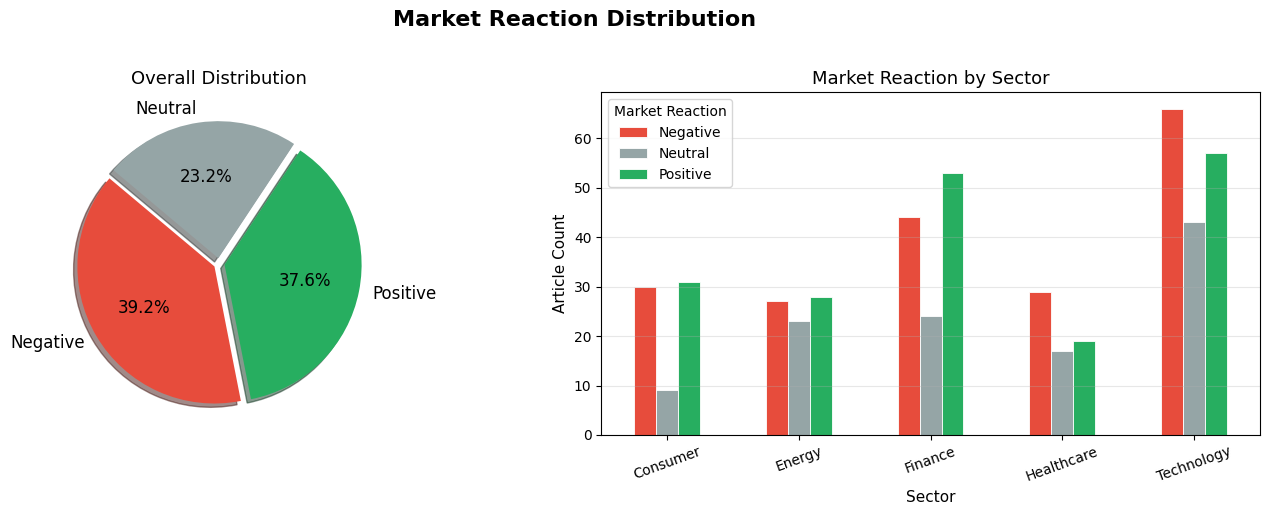

💾 Plot saved.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 — EDA Plot 1: Market Reaction Distribution (Pie + Bar)
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Market Reaction Distribution', fontsize=16, fontweight='bold', y=1.02)

colors = {'Positive': '#27ae60', 'Negative': '#e74c3c', 'Neutral': '#95a5a6'}
reaction_counts = df['Market_Reaction'].value_counts()

# Pie chart
axes[0].pie(
    reaction_counts.values,
    labels=reaction_counts.index,
    autopct='%1.1f%%',
    colors=[colors[k] for k in reaction_counts.index],
    startangle=140,
    explode=[0.04] * len(reaction_counts),
    shadow=True,
    textprops={'fontsize': 12}
)
axes[0].set_title('Overall Distribution', fontsize=13)

# Bar chart per sector
sector_react = df.groupby(['Sector', 'Market_Reaction']).size().unstack(fill_value=0)
sector_react.plot(
    kind='bar', ax=axes[1],
    color=[colors.get(c, '#aaa') for c in sector_react.columns],
    edgecolor='white', linewidth=0.6
)
axes[1].set_title('Market Reaction by Sector', fontsize=13)
axes[1].set_xlabel('Sector', fontsize=11)
axes[1].set_ylabel('Article Count', fontsize=11)
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(title='Market Reaction', fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('plot_01_reaction_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Plot saved.')

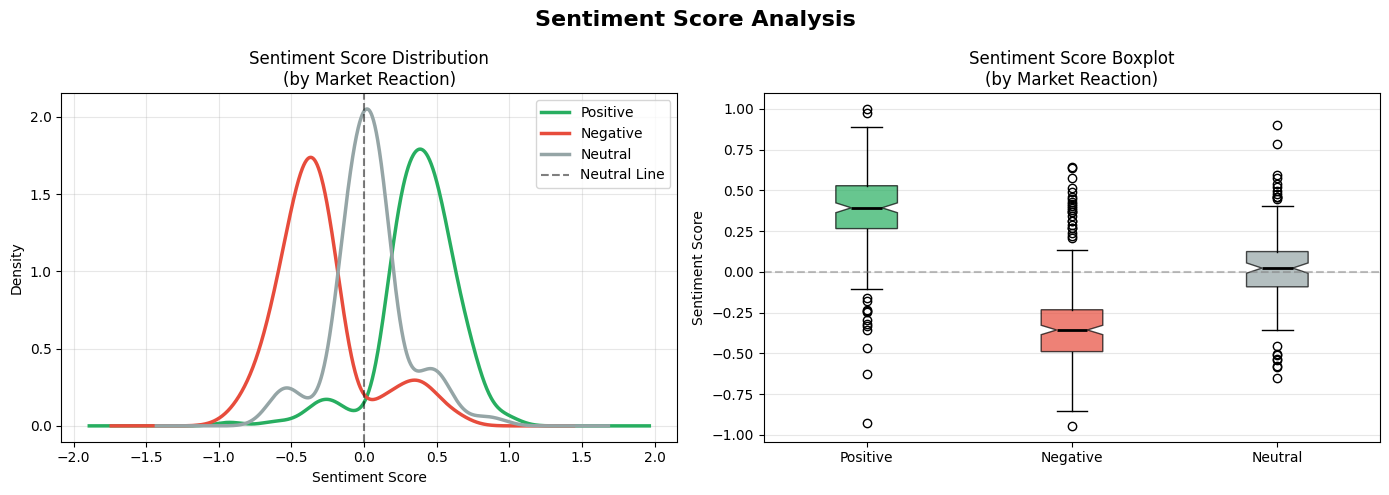

💾 Plot saved.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — EDA Plot 2: Sentiment Score Distribution by Market Reaction
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Sentiment Score Analysis', fontsize=16, fontweight='bold')

# KDE plot
for reaction, color in colors.items():
    subset = df[df['Market_Reaction'] == reaction]['Sentiment_Score']
    subset.plot.kde(ax=axes[0], label=reaction, color=color, linewidth=2.5)

axes[0].set_title('Sentiment Score Distribution\n(by Market Reaction)', fontsize=12)
axes[0].set_xlabel('Sentiment Score')
axes[0].axvline(0, color='black', linestyle='--', alpha=0.5, label='Neutral Line')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Boxplot
data_to_plot = [df[df['Market_Reaction'] == r]['Sentiment_Score'].values
                for r in ['Positive', 'Negative', 'Neutral']]
bp = axes[1].boxplot(data_to_plot, labels=['Positive', 'Negative', 'Neutral'],
                     patch_artist=True, notch=True,
                     medianprops={'color': 'black', 'linewidth': 2})
for patch, color in zip(bp['boxes'], [colors['Positive'], colors['Negative'], colors['Neutral']]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Sentiment Score Boxplot\n(by Market Reaction)', fontsize=12)
axes[1].set_ylabel('Sentiment Score')
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('plot_02_sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Plot saved.')

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 — EDA Plot 3: Interactive Scatter — Sentiment vs DJIA Return
# ─────────────────────────────────────────────────────────────────────────────
fig = px.scatter(
    df,
    x='Sentiment_Score',
    y='DJIA_Return',
    color='Market_Reaction',
    symbol='Event_Type',
    size='Volatility_Index',
    hover_data=['Headline', 'Sector', 'Date', 'Source'],
    color_discrete_map={'Positive': '#27ae60', 'Negative': '#e74c3c', 'Neutral': '#7f8c8d'},
    title='📈 Sentiment Score vs DJIA Daily Return  |  Bubble Size = Volatility Index',
    labels={
        'Sentiment_Score': 'News Sentiment Score (−1 to +1)',
        'DJIA_Return': 'DJIA Daily Return (%)',
        'Market_Reaction': 'Market Reaction'
    },
    template='plotly_white',
    opacity=0.75
)
fig.add_hline(y=0, line_dash='dash', line_color='gray', opacity=0.5,
              annotation_text=' Zero Return', annotation_position='right')
fig.add_vline(x=0, line_dash='dash', line_color='gray', opacity=0.5,
              annotation_text='Neutral Sentiment', annotation_position='top')
fig.update_layout(
    title_font_size=15,
    height=540,
    legend_title_text='Market Reaction',
    font=dict(family='Arial', size=12)
)
fig.show()
print('💡 Hover over any point to see the headline, source, and sector!')

💡 Hover over any point to see the headline, source, and sector!


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8 — EDA Plot 4: Time Series — DJIA Return + Rolling Sentiment
# ─────────────────────────────────────────────────────────────────────────────
df_time = df.sort_values('Date').copy()
df_time['Rolling_Sentiment'] = df_time['Sentiment_Score'].rolling(20, min_periods=1).mean()
df_time['Rolling_Return']    = df_time['DJIA_Return'].rolling(20, min_periods=1).mean()

fig = make_subplots(
    rows=3, cols=1,
    shared_xaxes=True,
    subplot_titles=(
        '📊 DJIA Daily Return (%) over Time',
        '📉 20-Day Rolling Average: News Sentiment Score',
        '🌡️ Volatility Index over Time'
    ),
    vertical_spacing=0.07,
    row_heights=[0.4, 0.3, 0.3]
)

# Panel 1: DJIA returns coloured green/red
for _, row in df_time.iterrows():
    clr = '#27ae60' if row['DJIA_Return'] >= 0 else '#e74c3c'
    fig.add_trace(
        go.Bar(x=[row['Date']], y=[row['DJIA_Return']],
               marker_color=clr, showlegend=False, opacity=0.7),
        row=1, col=1
    )

# Panel 2: Rolling sentiment
fig.add_trace(
    go.Scatter(x=df_time['Date'], y=df_time['Rolling_Sentiment'],
               mode='lines', line=dict(color='#2980b9', width=2.5),
               name='Rolling Sentiment', fill='tozeroy',
               fillcolor='rgba(41,128,185,0.1)'),
    row=2, col=1
)
fig.add_hline(y=0, line_dash='dot', line_color='gray', row=2, col=1, opacity=0.5)

# Panel 3: Volatility
fig.add_trace(
    go.Scatter(x=df_time['Date'], y=df_time['Volatility_Index'],
               mode='lines', line=dict(color='#8e44ad', width=1.5),
               name='Volatility Index'),
    row=3, col=1
)

fig.update_layout(
    title_text='📅 Financial News Sentiment & Market Indicators — 2021 to 2024',
    title_font_size=15,
    height=700,
    template='plotly_white',
    showlegend=False,
    font=dict(family='Arial', size=11)
)
fig.show()

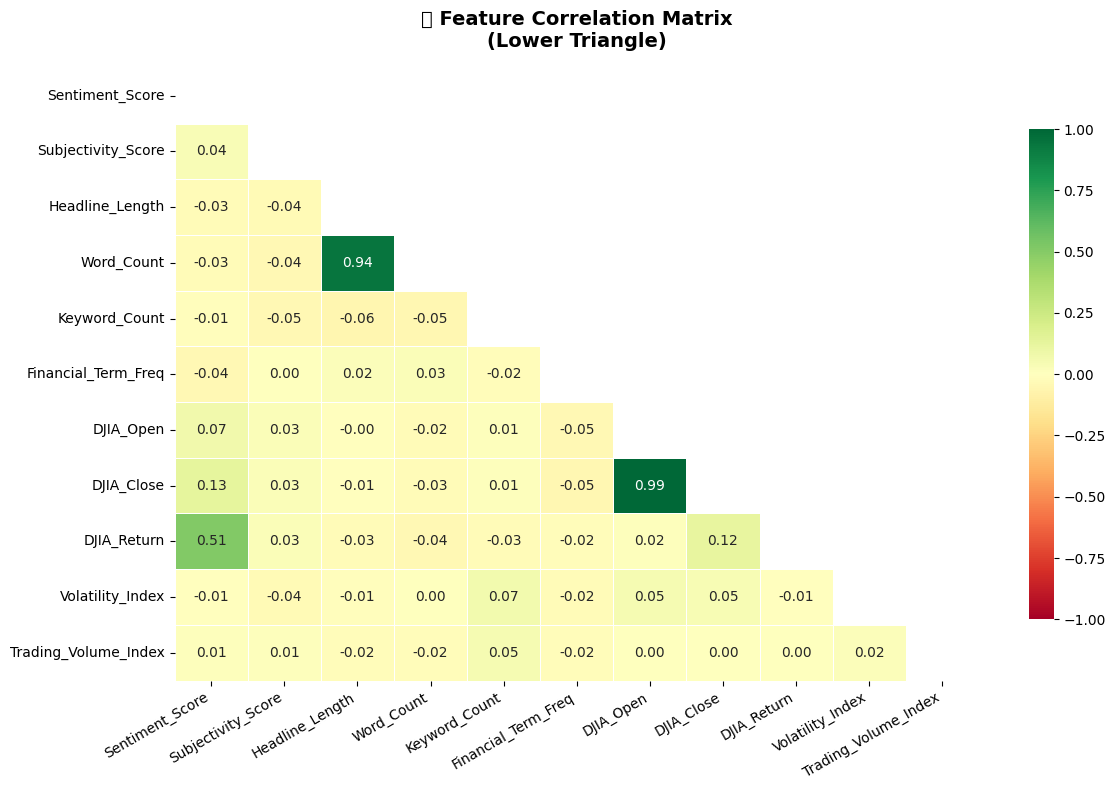

💡 Key insight: Sentiment_Score and DJIA_Return show the strongest positive correlation.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 9 — EDA Plot 5: Correlation Heatmap
# ─────────────────────────────────────────────────────────────────────────────
plt.figure(figsize=(12, 8))
corr_matrix = df[numeric_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt='.2f', cmap='RdYlGn',
    vmin=-1, vmax=1, center=0,
    linewidths=0.5, linecolor='white',
    cbar_kws={'shrink': 0.8}
)
plt.title('📊 Feature Correlation Matrix\n(Lower Triangle)', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig('plot_03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Key insight: Sentiment_Score and DJIA_Return show the strongest positive correlation.')

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 10 — EDA Plot 6: Sentiment by Sector (Interactive)
# ─────────────────────────────────────────────────────────────────────────────
sector_sentiment = df.groupby(['Sector', 'Market_Reaction']).size().reset_index(name='Count')

fig = px.bar(
    sector_sentiment,
    x='Sector', y='Count', color='Market_Reaction',
    barmode='group',
    color_discrete_map={'Positive': '#27ae60', 'Negative': '#e74c3c', 'Neutral': '#95a5a6'},
    title='📊 Market Reaction Distribution Across Sectors',
    template='plotly_white',
    labels={'Count': 'Number of Articles'},
    text='Count'
)
fig.update_traces(textposition='outside')
fig.update_layout(
    title_font_size=15, height=480,
    xaxis_tickangle=-20,
    font=dict(family='Arial', size=12),
    legend_title_text='Market Reaction'
)
fig.show()

# Average sentiment by event type
event_avg = df.groupby('Event_Type')['Sentiment_Score'].mean().sort_values()
fig2 = px.bar(
    event_avg.reset_index(),
    x='Sentiment_Score', y='Event_Type',
    orientation='h',
    color='Sentiment_Score',
    color_continuous_scale='RdYlGn',
    title='🏷️ Average Sentiment Score by Event Type',
    template='plotly_white',
    labels={'Sentiment_Score': 'Avg Sentiment Score', 'Event_Type': 'Event Type'}
)
fig2.update_layout(title_font_size=15, height=360, font=dict(family='Arial', size=12))
fig2.show()

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 11 — Feature Engineering
# ─────────────────────────────────────────────────────────────────────────────
df_ml = df.copy()

# ── Encode categorical columns ────────────────────────────────────────────────
le_dict = {}
for col in ['Sector', 'Region', 'Event_Type', 'Sentiment_Label', 'Source']:
    le = LabelEncoder()
    df_ml[col + '_enc'] = le.fit_transform(df_ml[col])
    le_dict[col] = le

# ── Derived features ──────────────────────────────────────────────────────────
df_ml['Sentiment_x_Volume'] = df_ml['Sentiment_Score'] * df_ml['Trading_Volume_Index']
df_ml['Return_per_Volatility'] = df_ml['DJIA_Return'] / (df_ml['Volatility_Index'] + 0.01)
df_ml['Subjectivity_Bias'] = df_ml['Subjectivity_Score'] * df_ml['Sentiment_Score']

# ── Feature set for ML ────────────────────────────────────────────────────────
feature_cols = [
    'Sentiment_Score', 'Subjectivity_Score', 'Headline_Length',
    'Word_Count', 'Keyword_Count', 'Financial_Term_Freq',
    'DJIA_Return', 'Volatility_Index', 'Trading_Volume_Index',
    'Sector_enc', 'Region_enc', 'Event_Type_enc', 'Sentiment_Label_enc',
    'Sentiment_x_Volume', 'Return_per_Volatility', 'Subjectivity_Bias'
]

X = df_ml[feature_cols].values
y = df_ml['Market_Reaction'].values

# ── Scale features ────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── Encode target ─────────────────────────────────────────────────────────────
le_target = LabelEncoder()
y_enc = le_target.fit_transform(y)

print(f'✅ Feature matrix shape : {X_scaled.shape}')
print(f'✅ Target classes       : {le_target.classes_}')
print(f'✅ Derived features added: Sentiment×Volume, Return/Volatility, Subjectivity Bias')

# Feature importance preview
feat_df = pd.DataFrame({'Feature': feature_cols})
print('\n📋 Feature List:')
display(feat_df)

✅ Feature matrix shape : (500, 16)
✅ Target classes       : ['Negative' 'Neutral' 'Positive']
✅ Derived features added: Sentiment×Volume, Return/Volatility, Subjectivity Bias

📋 Feature List:


,Feature
0,Sentiment_Score
1,Subjectivity_Score
2,Headline_Length
3,Word_Count
4,Keyword_Count
5,Financial_Term_Freq
6,DJIA_Return
7,Volatility_Index
8,Trading_Volume_Index
9,Sector_enc


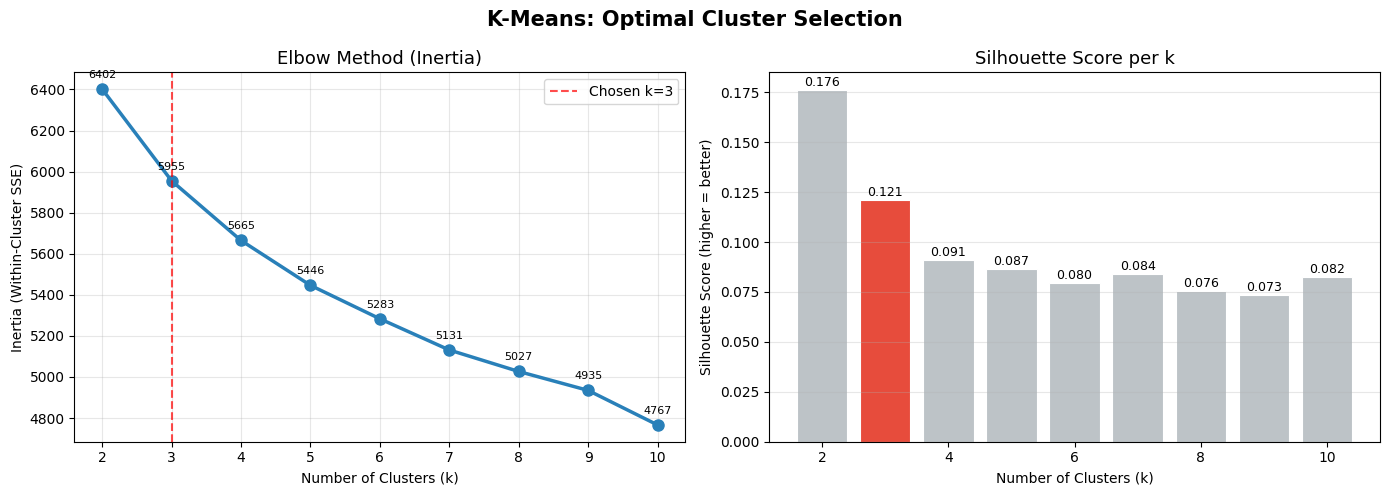

✅ Optimal k = 3 selected  (aligns with 3 market reaction classes: Positive/Negative/Neutral)


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 12 — Elbow Method + Silhouette Scores to find optimal k
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.metrics import silhouette_score

inertias   = []
silhouettes = []
K_range    = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('K-Means: Optimal Cluster Selection', fontsize=15, fontweight='bold')

# Elbow curve
axes[0].plot(list(K_range), inertias, 'o-', color='#2980b9', linewidth=2.5, markersize=8)
axes[0].axvline(x=3, color='red', linestyle='--', alpha=0.7, label='Chosen k=3')
axes[0].set_title('Elbow Method (Inertia)', fontsize=13)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-Cluster SSE)')
axes[0].legend()
axes[0].grid(alpha=0.3)
for i, v in enumerate(inertias):
    axes[0].annotate(f'{v:.0f}', (list(K_range)[i], v),
                     textcoords='offset points', xytext=(0, 8), fontsize=8, ha='center')

# Silhouette scores
bar_colors = ['#e74c3c' if k == 3 else '#bdc3c7' for k in K_range]
axes[1].bar(list(K_range), silhouettes, color=bar_colors, edgecolor='white', linewidth=0.8)
axes[1].set_title('Silhouette Score per k', fontsize=13)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score (higher = better)')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(silhouettes):
    axes[1].text(list(K_range)[i], v + 0.002, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('plot_04_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Optimal k = 3 selected  (aligns with 3 market reaction classes: Positive/Negative/Neutral)')

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 13 — Fit K-Means with k=3
# ─────────────────────────────────────────────────────────────────────────────
K_OPTIMAL = 3
kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=15, max_iter=300)
cluster_labels = kmeans.fit_predict(X_scaled)
df_ml['Cluster'] = cluster_labels

# Cluster profiling
print('\n📊 CLUSTER PROFILES')
print('─' * 60)
cluster_profile = df_ml.groupby('Cluster').agg(
    Count         = ('Market_Reaction', 'count'),
    Avg_Sentiment = ('Sentiment_Score', 'mean'),
    Avg_Return    = ('DJIA_Return',    'mean'),
    Avg_Volatility= ('Volatility_Index','mean'),
    Pos_Rate      = ('Market_Reaction', lambda x: (x=='Positive').mean()),
    Neg_Rate      = ('Market_Reaction', lambda x: (x=='Negative').mean()),
    Neu_Rate      = ('Market_Reaction', lambda x: (x=='Neutral').mean()),
).round(3)
display(cluster_profile)

# Dominant reaction per cluster → assign interpretable names
cluster_names = {}
for c in range(K_OPTIMAL):
    sub = df_ml[df_ml['Cluster'] == c]['Market_Reaction']
    dominant = sub.value_counts().idxmax()
    cluster_names[c] = f'Cluster {c}: {dominant}-leaning'

print('\n🔖 Cluster Interpretation:')
for k, v in cluster_names.items():
    print(f'   {v}')


📊 CLUSTER PROFILES
────────────────────────────────────────────────────────────


,Count,Avg_Sentiment,Avg_Return,Avg_Volatility,Pos_Rate,Neg_Rate,Neu_Rate
Cluster,,,,,,,
0,163,0.394,0.584,14.932,0.699,0.129,0.172
1,132,0.206,0.172,15.522,0.462,0.136,0.402
2,205,-0.374,-0.498,14.858,0.063,0.766,0.171



🔖 Cluster Interpretation:
   Cluster 0: Positive-leaning
   Cluster 1: Positive-leaning
   Cluster 2: Negative-leaning


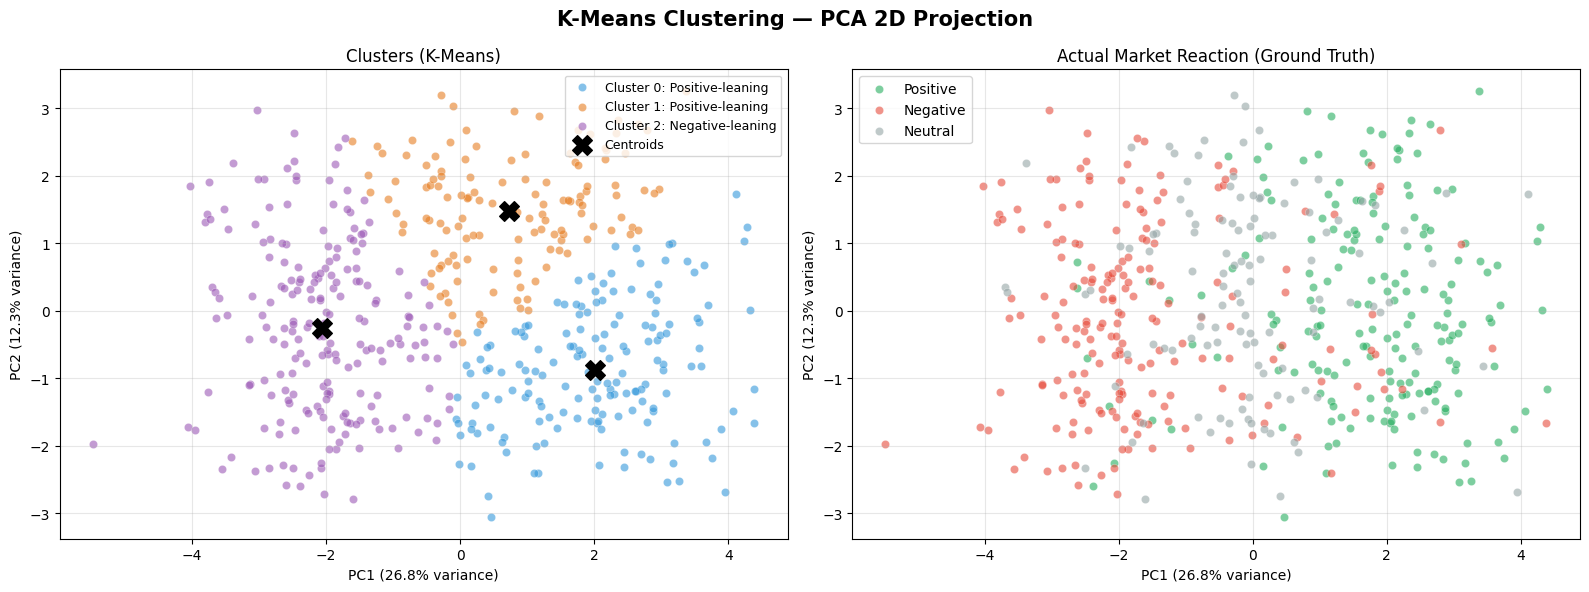

📐 Total variance explained by 2 PCs: 39.1%
💡 Comparing left vs right panels shows how well K-Means clusters align with actual reactions.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 14 — PCA Visualisation of K-Means Clusters
# ─────────────────────────────────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Cluster': cluster_labels.astype(str),
    'Market_Reaction': df_ml['Market_Reaction'],
    'Sentiment_Score': df_ml['Sentiment_Score'],
    'Sector': df_ml['Sector'],
    'DJIA_Return': df_ml['DJIA_Return']
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('K-Means Clustering — PCA 2D Projection', fontsize=15, fontweight='bold')

cluster_colors = {0: '#3498db', 1: '#e67e22', 2: '#9b59b6'}

# Left: coloured by cluster
for c in range(K_OPTIMAL):
    mask_c = cluster_labels == c
    axes[0].scatter(X_pca[mask_c, 0], X_pca[mask_c, 1],
                    c=cluster_colors[c], alpha=0.6, s=35,
                    label=cluster_names[c], edgecolors='white', linewidths=0.3)
# Plot centroids (projected)
centroids_pca = pca.transform(kmeans.cluster_centers_)
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1],
                s=200, c='black', marker='X', zorder=5, label='Centroids')
axes[0].set_title('Clusters (K-Means)', fontsize=12)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[0].legend(fontsize=9, loc='upper right')
axes[0].grid(alpha=0.3)

# Right: coloured by actual market reaction
for reaction, color in colors.items():
    mask_r = df_ml['Market_Reaction'].values == reaction
    axes[1].scatter(X_pca[mask_r, 0], X_pca[mask_r, 1],
                    c=color, alpha=0.6, s=35, label=reaction,
                    edgecolors='white', linewidths=0.3)
axes[1].set_title('Actual Market Reaction (Ground Truth)', fontsize=12)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

var_explained = sum(pca.explained_variance_ratio_) * 100
plt.tight_layout()
plt.savefig('plot_05_pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'📐 Total variance explained by 2 PCs: {var_explained:.1f}%')
print(f'💡 Comparing left vs right panels shows how well K-Means clusters align with actual reactions.')

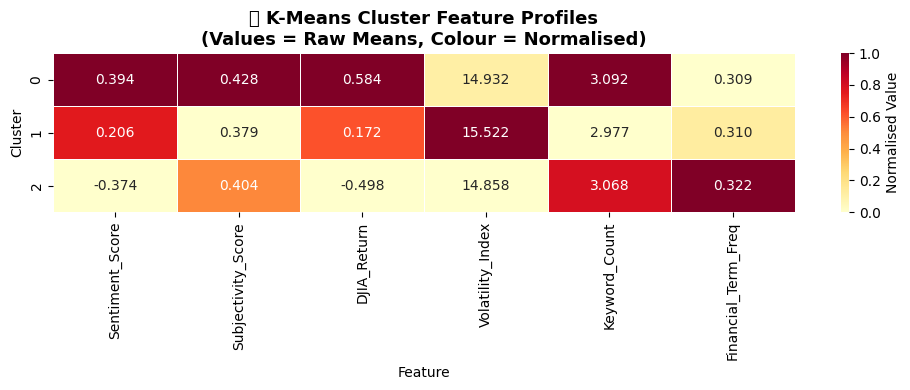


📋 Cluster Composition (Market Reaction breakdown):


Market_Reaction,Negative,Neutral,Positive
Cluster,,,
0,12.9,17.2,69.9
1,13.6,40.2,46.2
2,76.6,17.1,6.3


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 15 — Cluster Radar / Heatmap Profile
# ─────────────────────────────────────────────────────────────────────────────
profile_features = ['Sentiment_Score', 'Subjectivity_Score', 'DJIA_Return',
                     'Volatility_Index', 'Keyword_Count', 'Financial_Term_Freq']
cluster_means = df_ml.groupby('Cluster')[profile_features].mean()

# Normalize for heatmap
cluster_means_norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

plt.figure(figsize=(10, 4))
sns.heatmap(
    cluster_means_norm,
    annot=cluster_means.round(3),
    fmt='.3f',
    cmap='YlOrRd',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Normalised Value'}
)
plt.title('🔥 K-Means Cluster Feature Profiles\n(Values = Raw Means, Colour = Normalised)',
          fontsize=13, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Cluster')
plt.tight_layout()
plt.savefig('plot_06_cluster_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Cluster composition
print('\n📋 Cluster Composition (Market Reaction breakdown):')
display(pd.crosstab(df_ml['Cluster'], df_ml['Market_Reaction'], normalize='index').round(3) * 100)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 16 — Prepare data with Cluster as additional feature (HYBRID)
# ─────────────────────────────────────────────────────────────────────────────
feature_cols_hybrid = feature_cols + ['Cluster']  # add K-Means cluster as feature

X_hybrid = df_ml[feature_cols_hybrid].values
y_target  = df_ml['Market_Reaction'].values

# Encode target
le_target = LabelEncoder()
y_enc = le_target.fit_transform(y_target)

# Scale
X_hybrid_scaled = StandardScaler().fit_transform(X_hybrid)

# Train / test split: 80% train, 20% test — stratified
X_train, X_test, y_train, y_test = train_test_split(
    X_hybrid_scaled, y_enc,
    test_size=0.20, random_state=42, stratify=y_enc
)

print(f'✅ Training samples : {X_train.shape[0]} ({X_train.shape[0]/len(X_hybrid)*100:.0f}%)')
print(f'✅ Testing samples  : {X_test.shape[0]} ({X_test.shape[0]/len(X_hybrid)*100:.0f}%)')
print(f'✅ Feature count    : {X_hybrid_scaled.shape[1]} (includes K-Means Cluster feature)')
print(f'✅ Classes          : {le_target.classes_}')

✅ Training samples : 400 (80%)
✅ Testing samples  : 100 (20%)
✅ Feature count    : 17 (includes K-Means Cluster feature)
✅ Classes          : ['Negative' 'Neutral' 'Positive']


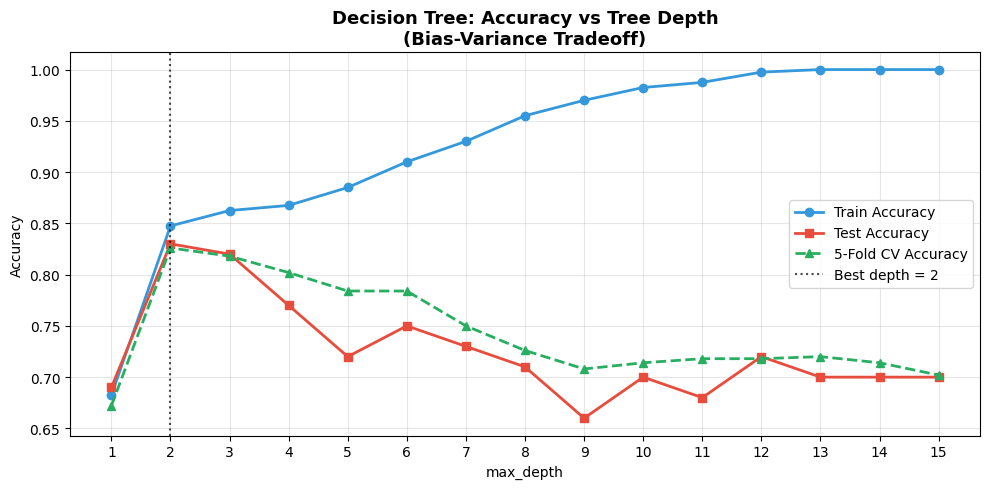

✅ Optimal max_depth = 2  (highest 5-fold CV accuracy = 0.8260)


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 17 — Hyperparameter Tuning: max_depth selection
# ─────────────────────────────────────────────────────────────────────────────
depth_scores_train = []
depth_scores_test  = []
depth_cv_scores    = []
depths = range(1, 16)

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42, class_weight='balanced')
    dt.fit(X_train, y_train)
    depth_scores_train.append(accuracy_score(y_train, dt.predict(X_train)))
    depth_scores_test.append(accuracy_score(y_test, dt.predict(X_test)))
    cv = cross_val_score(dt, X_hybrid_scaled, y_enc, cv=5, scoring='accuracy')
    depth_cv_scores.append(cv.mean())

best_depth = depths[np.argmax(depth_cv_scores)]

plt.figure(figsize=(10, 5))
plt.plot(depths, depth_scores_train, 'o-', color='#3498db', label='Train Accuracy', linewidth=2)
plt.plot(depths, depth_scores_test,  's-', color='#e74c3c', label='Test Accuracy',  linewidth=2)
plt.plot(depths, depth_cv_scores,    '^--',color='#27ae60', label='5-Fold CV Accuracy', linewidth=2)
plt.axvline(x=best_depth, color='black', linestyle=':', alpha=0.7, label=f'Best depth = {best_depth}')
plt.title('Decision Tree: Accuracy vs Tree Depth\n(Bias-Variance Tradeoff)', fontsize=13, fontweight='bold')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(list(depths))
plt.tight_layout()
plt.savefig('plot_07_depth_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Optimal max_depth = {best_depth}  (highest 5-fold CV accuracy = {max(depth_cv_scores):.4f})')

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 18 — Train Final Decision Tree Model
# ─────────────────────────────────────────────────────────────────────────────
dt_final = DecisionTreeClassifier(
    max_depth=best_depth,
    min_samples_split=8,
    min_samples_leaf=4,
    class_weight='balanced',
    random_state=42
)
dt_final.fit(X_train, y_train)

y_pred_train = dt_final.predict(X_train)
y_pred_test  = dt_final.predict(X_test)

train_acc = accuracy_score(y_train, y_pred_train)
test_acc  = accuracy_score(y_test,  y_pred_test)

print('=' * 55)
print('   🌳 DECISION TREE — TRAINING RESULTS')
print('=' * 55)
print(f'   Training Accuracy   : {train_acc:.4f} ({train_acc*100:.2f}%)')
print(f'   Test Accuracy       : {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'   Overfitting Gap     : {(train_acc - test_acc)*100:.2f}%')
print('=' * 55)
print('\n📋 CLASSIFICATION REPORT (Test Set):')
print(classification_report(y_test, y_pred_test, target_names=le_target.classes_))

   🌳 DECISION TREE — TRAINING RESULTS
   Training Accuracy   : 0.8475 (84.75%)
   Test Accuracy       : 0.8300 (83.00%)
   Overfitting Gap     : 1.75%

📋 CLASSIFICATION REPORT (Test Set):
              precision    recall  f1-score   support

    Negative       0.81      0.90      0.85        39
     Neutral       0.84      0.70      0.76        23
    Positive       0.84      0.84      0.84        38

    accuracy                           0.83       100
   macro avg       0.83      0.81      0.82       100
weighted avg       0.83      0.83      0.83       100



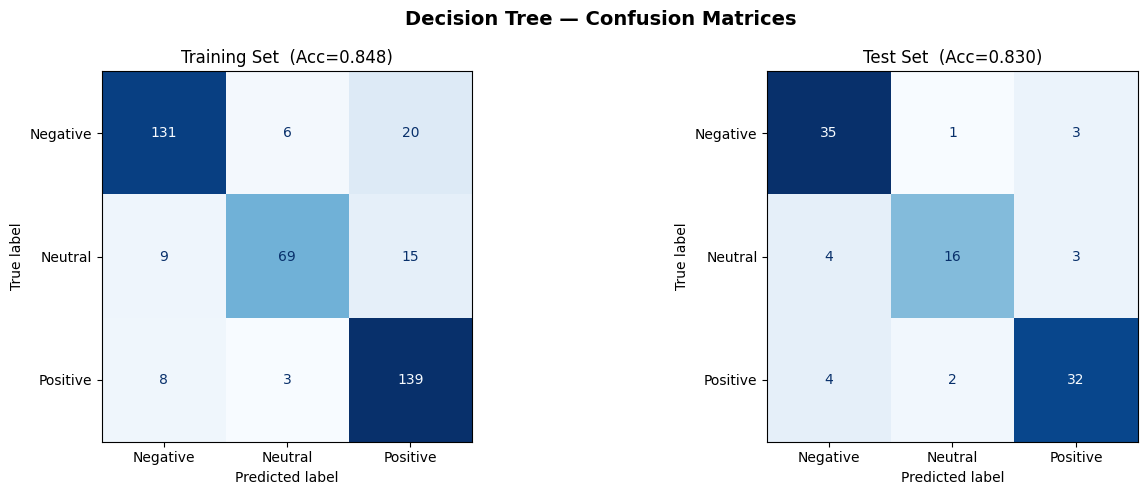

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 19 — Confusion Matrix
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Decision Tree — Confusion Matrices', fontsize=14, fontweight='bold')

for ax, (y_true, y_hat, title) in zip(
    axes,
    [(y_train, y_pred_train, f'Training Set  (Acc={train_acc:.3f})'),
     (y_test,  y_pred_test,  f'Test Set  (Acc={test_acc:.3f})')]
):
    cm = confusion_matrix(y_true, y_hat)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_target.classes_)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title, fontsize=12)

plt.tight_layout()
plt.savefig('plot_08_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

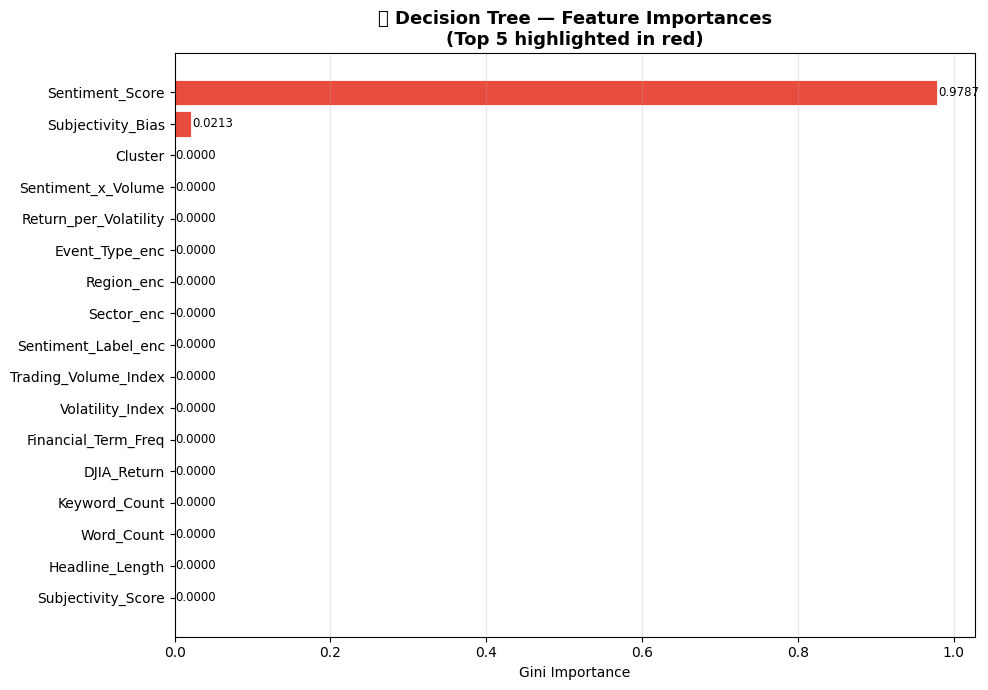


🔑 Top 5 Most Important Features:
   1. Sentiment_Score                 0.9787
   2. Subjectivity_Bias               0.0213
   3. Return_per_Volatility           0.0000
   4. Cluster                         0.0000
   5. Sentiment_x_Volume              0.0000


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 20 — Feature Importance Plot
# ─────────────────────────────────────────────────────────────────────────────
importances = dt_final.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature':    feature_cols_hybrid,
    'Importance': importances
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 7))
bar_colors = ['#e74c3c' if i >= len(feat_imp_df) - 5 else '#3498db'
              for i in range(len(feat_imp_df))]
plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'],
         color=bar_colors, edgecolor='white', linewidth=0.6)
plt.title('🌳 Decision Tree — Feature Importances\n(Top 5 highlighted in red)',
          fontsize=13, fontweight='bold')
plt.xlabel('Gini Importance')
plt.grid(axis='x', alpha=0.3)
for i, (val, feat) in enumerate(zip(feat_imp_df['Importance'], feat_imp_df['Feature'])):
    plt.text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=8.5)
plt.tight_layout()
plt.savefig('plot_09_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n🔑 Top 5 Most Important Features:')
top5 = feat_imp_df.tail(5).sort_values('Importance', ascending=False)
for i, (_, row) in enumerate(top5.iterrows(), 1):
    print(f'   {i}. {row["Feature"]:30s}  {row["Importance"]:.4f}')

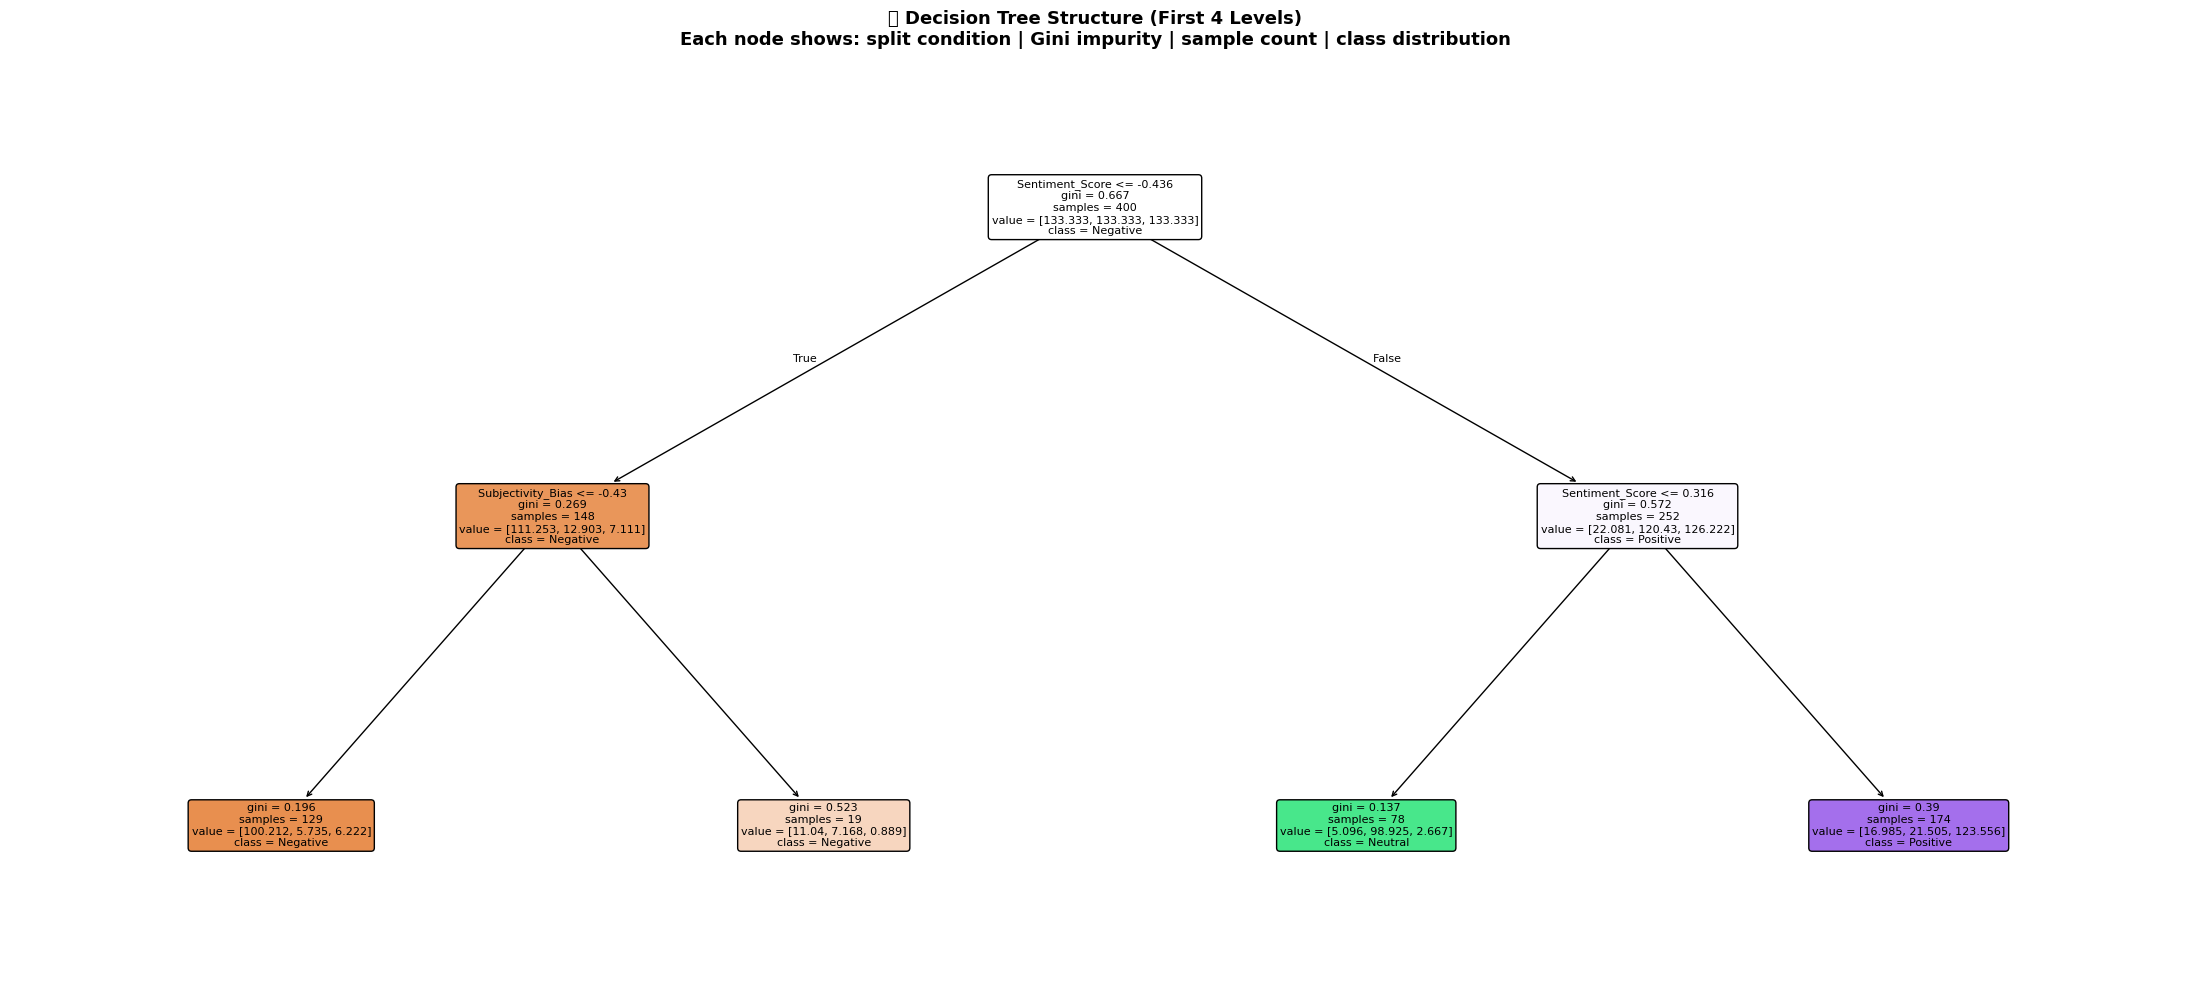

🔎 Deeper levels exist but are hidden for readability.
📊 Full tree depth: 2 levels | 4 leaf nodes


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 21 — Decision Tree Visualisation (top 4 levels)
# ─────────────────────────────────────────────────────────────────────────────
plt.figure(figsize=(22, 10))
plot_tree(
    dt_final,
    max_depth=4,
    feature_names=feature_cols_hybrid,
    class_names=le_target.classes_,
    filled=True,
    rounded=True,
    fontsize=8,
    impurity=True,
    proportion=False
)
plt.title('🌳 Decision Tree Structure (First 4 Levels)\n'
          'Each node shows: split condition | Gini impurity | sample count | class distribution',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_10_decision_tree.png', dpi=120, bbox_inches='tight')
plt.show()
print('🔎 Deeper levels exist but are hidden for readability.')
print(f'📊 Full tree depth: {dt_final.get_depth()} levels | {dt_final.get_n_leaves()} leaf nodes')


   📊 5-FOLD CROSS-VALIDATION RESULTS
   Fold 1: █████████████████████████████████████████  0.8200
   Fold 2: █████████████████████████████████████████  0.8200
   Fold 3: ██████████████████████████████████████████  0.8400
   Fold 4: ████████████████████████████████████████████  0.8900
   Fold 5: █████████████████████████████████████████  0.8200
───────────────────────────────────────────────────────
   Mean CV Accuracy  : 0.8380 ± 0.0271
   Best Fold         : 0.8900
   Worst Fold        : 0.8200


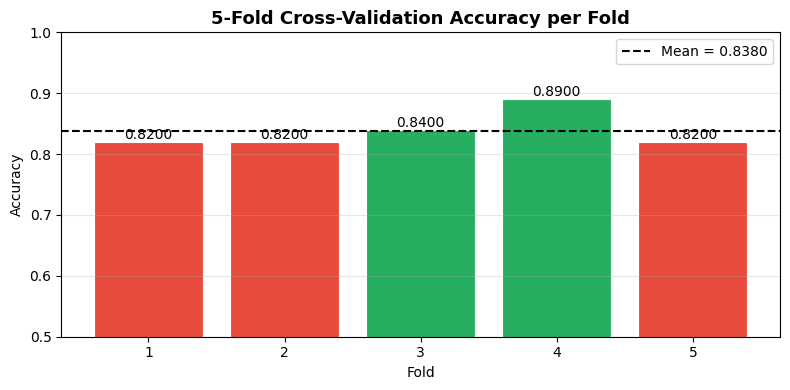

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 22 — Cross-Validation Performance Summary
# ─────────────────────────────────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(dt_final, X_hybrid_scaled, y_enc, cv=cv, scoring='accuracy')

print('\n' + '='*55)
print('   📊 5-FOLD CROSS-VALIDATION RESULTS')
print('='*55)
for i, s in enumerate(cv_scores, 1):
    bar = '█' * int(s * 50)
    print(f'   Fold {i}: {bar}  {s:.4f}')
print('─'*55)
print(f'   Mean CV Accuracy  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'   Best Fold         : {cv_scores.max():.4f}')
print(f'   Worst Fold        : {cv_scores.min():.4f}')
print('='*55)

# Visual CV bar chart
plt.figure(figsize=(8, 4))
plt.bar(range(1, 6), cv_scores, color=['#27ae60' if s >= cv_scores.mean() else '#e74c3c' for s in cv_scores],
        edgecolor='white', linewidth=0.8)
plt.axhline(cv_scores.mean(), color='black', linestyle='--', linewidth=1.5, label=f'Mean = {cv_scores.mean():.4f}')
plt.title('5-Fold Cross-Validation Accuracy per Fold', fontsize=13, fontweight='bold')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.ylim(0.5, 1.0)
plt.legend()
plt.grid(axis='y', alpha=0.3)
for i, s in enumerate(cv_scores, 1):
    plt.text(i, s + 0.005, f'{s:.4f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('plot_11_crossval.png', dpi=150, bbox_inches='tight')
plt.show()


   🏆 HYBRID MODEL PERFORMANCE SUMMARY


,Metric,Value,Percentage
0,Train Accuracy,0.8475,84.75%
1,Test Accuracy,0.8300,83.0%
2,CV Mean Accuracy,0.8380,83.8%
3,Precision (macro),0.8327,83.27%
4,Recall (macro),0.8117,81.17%
5,F1-Score (macro),0.8192,81.92%


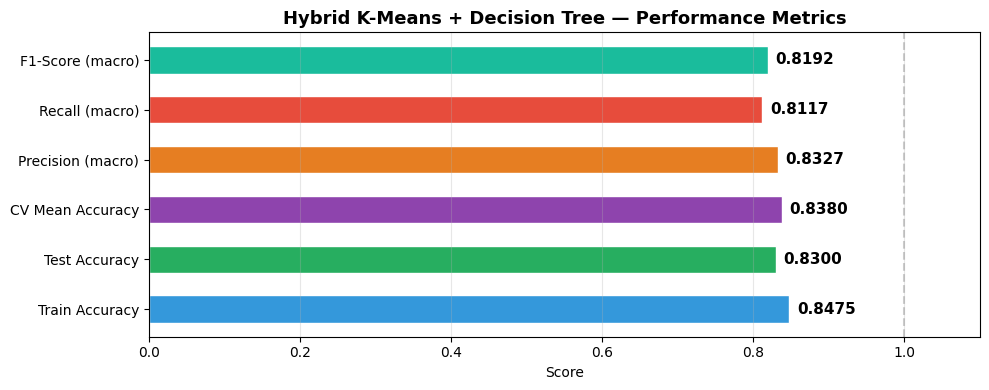

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 23 — Hybrid Model Performance Summary Dashboard
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.metrics import precision_score, recall_score, f1_score

metrics_summary = {
    'Metric': ['Train Accuracy', 'Test Accuracy', 'CV Mean Accuracy',
               'Precision (macro)', 'Recall (macro)', 'F1-Score (macro)'],
    'Value': [
        train_acc,
        test_acc,
        cv_scores.mean(),
        precision_score(y_test, y_pred_test, average='macro'),
        recall_score(y_test, y_pred_test, average='macro'),
        f1_score(y_test, y_pred_test, average='macro')
    ]
}

metrics_df = pd.DataFrame(metrics_summary)
metrics_df['Value'] = metrics_df['Value'].round(4)
metrics_df['Percentage'] = (metrics_df['Value'] * 100).round(2).astype(str) + '%'

print('\n' + '='*55)
print('   🏆 HYBRID MODEL PERFORMANCE SUMMARY')
print('='*55)
display(metrics_df)

# Gauge-style bar
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(metrics_summary['Metric'], metrics_summary['Value'],
               color=['#3498db','#27ae60','#8e44ad','#e67e22','#e74c3c','#1abc9c'],
               edgecolor='white', height=0.55)
ax.set_xlim(0, 1.1)
ax.axvline(1.0, color='gray', linestyle='--', alpha=0.4)
for bar, val in zip(bars, metrics_summary['Value']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=11, fontweight='bold')
ax.set_title('Hybrid K-Means + Decision Tree — Performance Metrics', fontsize=13, fontweight='bold')
ax.set_xlabel('Score')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('plot_12_performance_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 24 — Prediction Function
# ─────────────────────────────────────────────────────────────────────────────
# Refit scaler on full data for deployment
scaler_full = StandardScaler()
X_full_for_scaler = df_ml[feature_cols_hybrid].values
scaler_full.fit(X_full_for_scaler)

def predict_market_reaction(
    sentiment_score: float,
    subjectivity_score: float,
    headline_length: int,
    word_count: int,
    keyword_count: int,
    financial_term_freq: float,
    djia_return: float,
    volatility_index: float,
    trading_volume_index: float,
    sector: str = 'Technology',
    region: str = 'USA',
    event_type: str = 'Earnings',
    sentiment_label: str = 'Positive'
):
    """
    Predict market reaction for a new news article using the trained Hybrid model.
    Returns: predicted class, probabilities, and confidence level.
    """
    # Encode categoricals
    sector_enc      = le_dict['Sector'].transform([sector])[0]       if sector in le_dict['Sector'].classes_      else 0
    region_enc      = le_dict['Region'].transform([region])[0]       if region in le_dict['Region'].classes_      else 0
    event_enc       = le_dict['Event_Type'].transform([event_type])[0] if event_type in le_dict['Event_Type'].classes_ else 0
    sent_label_enc  = le_dict['Sentiment_Label'].transform([sentiment_label])[0] if sentiment_label in le_dict['Sentiment_Label'].classes_ else 1
    source_enc      = 0  # default

    # Derived features
    sent_x_vol     = sentiment_score * trading_volume_index
    ret_per_vol    = djia_return / (volatility_index + 0.01)
    subj_bias      = subjectivity_score * sentiment_score

    base_features = np.array([[
        sentiment_score, subjectivity_score, headline_length,
        word_count, keyword_count, financial_term_freq,
        djia_return, volatility_index, trading_volume_index,
        sector_enc, region_enc, event_enc, sent_label_enc,
        sent_x_vol, ret_per_vol, subj_bias
    ]])

    # Assign cluster
    base_scaled_for_cluster = scaler.transform(base_features)
    cluster_id = kmeans.predict(base_scaled_for_cluster)[0]

    # Full feature vector with cluster
    full_features = np.append(base_features[0], cluster_id).reshape(1, -1)
    full_scaled   = scaler_full.transform(full_features)

    # Predict
    pred_enc  = dt_final.predict(full_scaled)[0]
    pred_prob = dt_final.predict_proba(full_scaled)[0]
    pred_label = le_target.inverse_transform([pred_enc])[0]

    result = {
        'Predicted Reaction': pred_label,
        'Confidence'        : f'{max(pred_prob)*100:.1f}%',
        'K-Means Cluster'   : cluster_id,
        'Probabilities'     : dict(zip(le_target.classes_, pred_prob.round(4)))
    }
    return result

print('✅ Prediction function ready!')

✅ Prediction function ready!


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 25 — Run Predictions on 5 Test Scenarios
# ─────────────────────────────────────────────────────────────────────────────

scenarios = [
    {
        'name': '📈 Scenario 1: Strong Positive Earnings',
        'sentiment_score': 0.78, 'subjectivity_score': 0.52, 'headline_length': 85,
        'word_count': 16, 'keyword_count': 5, 'financial_term_freq': 0.62,
        'djia_return': 1.8, 'volatility_index': 14.2, 'trading_volume_index': 210.5,
        'sector': 'Technology', 'region': 'USA', 'event_type': 'Earnings', 'sentiment_label': 'Positive'
    },
    {
        'name': '📉 Scenario 2: Geopolitical Shock',
        'sentiment_score': -0.71, 'subjectivity_score': 0.68, 'headline_length': 92,
        'word_count': 18, 'keyword_count': 6, 'financial_term_freq': 0.45,
        'djia_return': -2.1, 'volatility_index': 38.5, 'trading_volume_index': 280.0,
        'sector': 'Energy', 'region': 'Global', 'event_type': 'Geopolitical', 'sentiment_label': 'Negative'
    },
    {
        'name': '⚖️ Scenario 3: Fed Holds Rates — Mixed Signals',
        'sentiment_score': 0.03, 'subjectivity_score': 0.38, 'headline_length': 70,
        'word_count': 13, 'keyword_count': 3, 'financial_term_freq': 0.38,
        'djia_return': 0.12, 'volatility_index': 18.0, 'trading_volume_index': 155.0,
        'sector': 'Finance', 'region': 'USA', 'event_type': 'Policy Change', 'sentiment_label': 'Neutral'
    },
    {
        'name': '🏥 Scenario 4: Drug Approval Surprise',
        'sentiment_score': 0.85, 'subjectivity_score': 0.44, 'headline_length': 78,
        'word_count': 15, 'keyword_count': 4, 'financial_term_freq': 0.55,
        'djia_return': 2.4, 'volatility_index': 11.0, 'trading_volume_index': 190.0,
        'sector': 'Healthcare', 'region': 'USA', 'event_type': 'Merger', 'sentiment_label': 'Positive'
    },
    {
        'name': '🏭 Scenario 5: Weak Manufacturing PMI',
        'sentiment_score': -0.55, 'subjectivity_score': 0.32, 'headline_length': 65,
        'word_count': 12, 'keyword_count': 3, 'financial_term_freq': 0.40,
        'djia_return': -0.9, 'volatility_index': 22.0, 'trading_volume_index': 175.0,
        'sector': 'Consumer', 'region': 'USA', 'event_type': 'Economic Data', 'sentiment_label': 'Negative'
    }
]

reaction_emoji = {'Positive': '🟢', 'Negative': '🔴', 'Neutral': '🟡'}

print('\n' + '='*65)
print('   🔮 FUTURE PREDICTION ENGINE — SCENARIO RESULTS')
print('='*65)

for sc in scenarios:
    name = sc.pop('name')
    result = predict_market_reaction(**sc)
    emoji = reaction_emoji[result['Predicted Reaction']]
    print(f'\n  {name}')
    print(f'  Predicted Reaction : {emoji} {result["Predicted Reaction"]}  |  Confidence: {result["Confidence"]}  |  Cluster: {result["K-Means Cluster"]}')
    probs = result['Probabilities']
    for cls, prob in probs.items():
        bar = '▓' * int(prob * 30)
        print(f'    {cls:10s} [{bar:<30s}] {prob:.4f}')

print('\n' + '='*65)


   🔮 FUTURE PREDICTION ENGINE — SCENARIO RESULTS

  📈 Scenario 1: Strong Positive Earnings
  Predicted Reaction : 🟢 Positive  |  Confidence: 76.2%  |  Cluster: 0
    Negative   [▓▓▓                           ] 0.1048
    Neutral    [▓▓▓                           ] 0.1327
    Positive   [▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓        ] 0.7625

  📉 Scenario 2: Geopolitical Shock
  Predicted Reaction : 🔴 Negative  |  Confidence: 89.3%  |  Cluster: 2
    Negative   [▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓    ] 0.8934
    Neutral    [▓                             ] 0.0511
    Positive   [▓                             ] 0.0555

  ⚖️ Scenario 3: Fed Holds Rates — Mixed Signals
  Predicted Reaction : 🟡 Neutral  |  Confidence: 92.7%  |  Cluster: 0
    Negative   [▓                             ] 0.0478
    Neutral    [▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓   ] 0.9272
    Positive   [                              ] 0.0250

  🏥 Scenario 4: Drug Approval Surprise
  Predicted Reaction : 🟢 Positive  |  Confidence: 76.2%  |  Cluster: 0
    

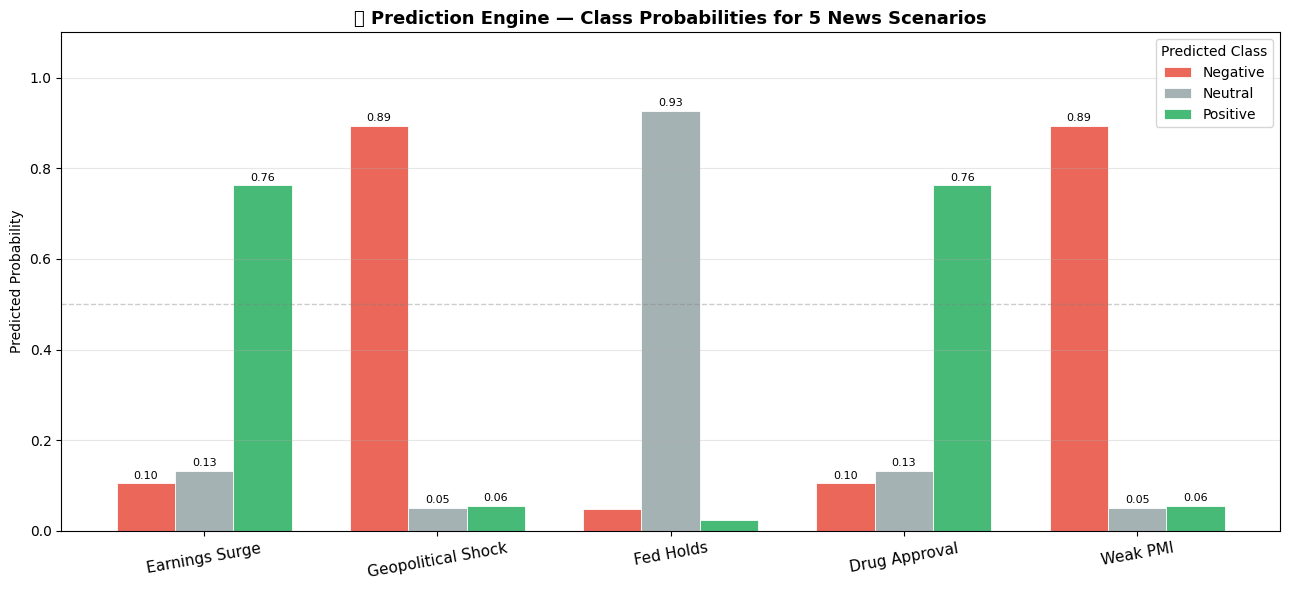

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 26 — Prediction Results Visual Dashboard
# ─────────────────────────────────────────────────────────────────────────────

# Re-run scenarios for plot
scenario_names_short = ['Earnings Surge', 'Geopolitical Shock', 'Fed Holds', 'Drug Approval', 'Weak PMI']
scenario_params = [
    {'sentiment_score': 0.78, 'subjectivity_score': 0.52, 'headline_length': 85, 'word_count': 16, 'keyword_count': 5, 'financial_term_freq': 0.62, 'djia_return': 1.8, 'volatility_index': 14.2, 'trading_volume_index': 210.5, 'sector': 'Technology', 'region': 'USA', 'event_type': 'Earnings', 'sentiment_label': 'Positive'},
    {'sentiment_score': -0.71, 'subjectivity_score': 0.68, 'headline_length': 92, 'word_count': 18, 'keyword_count': 6, 'financial_term_freq': 0.45, 'djia_return': -2.1, 'volatility_index': 38.5, 'trading_volume_index': 280.0, 'sector': 'Energy', 'region': 'Global', 'event_type': 'Geopolitical', 'sentiment_label': 'Negative'},
    {'sentiment_score': 0.03, 'subjectivity_score': 0.38, 'headline_length': 70, 'word_count': 13, 'keyword_count': 3, 'financial_term_freq': 0.38, 'djia_return': 0.12, 'volatility_index': 18.0, 'trading_volume_index': 155.0, 'sector': 'Finance', 'region': 'USA', 'event_type': 'Policy Change', 'sentiment_label': 'Neutral'},
    {'sentiment_score': 0.85, 'subjectivity_score': 0.44, 'headline_length': 78, 'word_count': 15, 'keyword_count': 4, 'financial_term_freq': 0.55, 'djia_return': 2.4, 'volatility_index': 11.0, 'trading_volume_index': 190.0, 'sector': 'Healthcare', 'region': 'USA', 'event_type': 'Merger', 'sentiment_label': 'Positive'},
    {'sentiment_score': -0.55, 'subjectivity_score': 0.32, 'headline_length': 65, 'word_count': 12, 'keyword_count': 3, 'financial_term_freq': 0.40, 'djia_return': -0.9, 'volatility_index': 22.0, 'trading_volume_index': 175.0, 'sector': 'Consumer', 'region': 'USA', 'event_type': 'Economic Data', 'sentiment_label': 'Negative'},
]

pred_results = [predict_market_reaction(**p) for p in scenario_params]

# Grouped bar chart: probability for each class per scenario
classes = le_target.classes_
class_colors = {'Negative': '#e74c3c', 'Neutral': '#95a5a6', 'Positive': '#27ae60'}

x = np.arange(len(scenario_names_short))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))
for i, cls in enumerate(classes):
    probs = [r['Probabilities'][cls] for r in pred_results]
    bars = ax.bar(x + (i - 1) * width, probs, width,
                  label=cls, color=class_colors[cls],
                  edgecolor='white', linewidth=0.7, alpha=0.85)
    for bar, p in zip(bars, probs):
        if p > 0.05:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{p:.2f}', ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(scenario_names_short, fontsize=11, rotation=10)
ax.set_ylabel('Predicted Probability')
ax.set_title('🔮 Prediction Engine — Class Probabilities for 5 News Scenarios',
             fontsize=13, fontweight='bold')
ax.legend(title='Predicted Class', fontsize=10)
ax.set_ylim(0, 1.1)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.4, linewidth=1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plot_13_prediction_scenarios.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 27 — Monthly Sentiment Trend Forecast (Rolling Prediction)
# ─────────────────────────────────────────────────────────────────────────────
df_monthly = df.set_index('Date').resample('M').agg({
    'Sentiment_Score': 'mean',
    'DJIA_Return': 'mean',
    'Volatility_Index': 'mean',
    'Trading_Volume_Index': 'mean'
}).reset_index()

# Monthly market reaction distribution
monthly_reaction = df.set_index('Date').resample('M')['Market_Reaction'].value_counts().unstack(fill_value=0)

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=[
        'Monthly Average Sentiment Score',
        'Monthly Average DJIA Return (%)',
        'Monthly Market Reaction Count',
        'Monthly Volatility Index'
    ],
    vertical_spacing=0.15, horizontal_spacing=0.10
)

fig.add_trace(go.Scatter(
    x=df_monthly['Date'], y=df_monthly['Sentiment_Score'],
    mode='lines+markers', line=dict(color='#2980b9', width=2),
    fill='tozeroy', fillcolor='rgba(41,128,185,0.12)', name='Sentiment'
), row=1, col=1)

fig.add_trace(go.Bar(
    x=df_monthly['Date'],
    y=df_monthly['DJIA_Return'],
    marker_color=['#27ae60' if v >= 0 else '#e74c3c' for v in df_monthly['DJIA_Return']],
    name='DJIA Return'
), row=1, col=2)

for reaction, color in {'Positive': '#27ae60', 'Negative': '#e74c3c', 'Neutral': '#95a5a6'}.items():
    if reaction in monthly_reaction.columns:
        fig.add_trace(go.Scatter(
            x=monthly_reaction.index,
            y=monthly_reaction[reaction],
            mode='lines', name=reaction,
            line=dict(color=color, width=1.8)
        ), row=2, col=1)

fig.add_trace(go.Scatter(
    x=df_monthly['Date'], y=df_monthly['Volatility_Index'],
    mode='lines+markers', line=dict(color='#8e44ad', width=2),
    fill='tozeroy', fillcolor='rgba(142,68,173,0.12)', name='Volatility'
), row=2, col=2)

fig.update_layout(
    title_text='📅 Monthly Trend Analysis — Sentiment, Returns & Market Reactions (2021–2024)',
    height=620, template='plotly_white',
    title_font_size=14, showlegend=True,
    font=dict(family='Arial', size=11)
)
fig.show()

In [ ]:
import subprocess, sys, os, time, re

# ── Download cloudflared fresh ────────────────────────────────
print("⬇️  Downloading cloudflared...")
subprocess.run([
    "wget", "-q",
    "https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64",
    "-O", "/usr/local/bin/cloudflared"
], check=True)
subprocess.run(["chmod", "+x", "/usr/local/bin/cloudflared"])

# Verify it downloaded correctly
result = subprocess.run(["cloudflared", "--version"], capture_output=True, text=True)
print(f"✅ cloudflared ready: {result.stdout.strip()}")

# ── Start tunnel ──────────────────────────────────────────────
print("⏳ Starting tunnel...")
tunnel = subprocess.Popen(
    ["cloudflared", "tunnel", "--url", "http://localhost:8501"],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

# ── Extract URL ───────────────────────────────────────────────
full_url = None
for _ in range(60):
    line = tunnel.stderr.readline().decode("utf8", errors="ignore")
    match = re.search(r"https://[a-zA-Z0-9\-]+\.trycloudflare\.com", line)
    if match:
        full_url = match.group(0)
        break
    time.sleep(0.5)

if full_url:
    print("\n" + "="*60)
    print("🚀  DASHBOARD IS LIVE!")
    print("="*60)
    print(f"\n   👉  {full_url}\n")
    print("="*60)
    print("✅ Open in any browser — no login needed!")
else:
    print("❌ URL not found. Check if Streamlit is still running:")
    check = subprocess.run(["curl", "-s", "-o", "/dev/null", "-w", "%{http_code}",
                             "http://localhost:8501"], capture_output=True, text=True)
    print(f"   Streamlit status code: {check.stdout}")
    print("   If not 200, re-run the full single cell first, then this cell.")

⬇️  Downloading cloudflared...
✅ cloudflared ready: cloudflared version 2026.3.0 (built 2026-03-09-14:08 UTC)
⏳ Starting tunnel...

🚀  DASHBOARD IS LIVE!

   👉  https://car-cold-parliamentary-game.trycloudflare.com

✅ Open in any browser — no login needed!


In [ ]:
import subprocess, threading, time, urllib.request

# Start Streamlit in background
proc = subprocess.Popen(
    ["streamlit", "run", "app.py",
     "--server.port=8501",
     "--server.headless=true",
     "--server.enableCORS=false",
     "--server.enableXsrfProtection=false"],
    stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
)

time.sleep(5)  # wait for Streamlit to boot

# Get your Colab's external IP (for the password prompt)
try:
    ip = urllib.request.urlopen("https://ipv4.icanhazip.com").read().decode("utf8").strip()
    print(f"📋 Your Colab IP (for password prompt): {ip}")
except:
    ip = "check above output"

print("\n⏳ Starting tunnel...")

📋 Your Colab IP (for password prompt): 34.9.211.2

⏳ Starting tunnel...


In [ ]:
# Run localtunnel in background and get URL
lt_proc = subprocess.Popen(
    ["lt", "--port", "8501"],
    stdout=subprocess.PIPE, stderr=subprocess.PIPE
)

time.sleep(3)
url_line = lt_proc.stdout.readline().decode("utf8").strip()
print("=" * 55)
print("🚀 Dashboard is LIVE at:")
print(f"   {url_line}")
print("=" * 55)
print(f"⚠️  If asked for a password, enter your IP: {ip}")
print("   (shown above, or visit https://ipv4.icanhazip.com)")

🚀 Dashboard is LIVE at:
   your url is: https://all-views-yell.loca.lt
⚠️  If asked for a password, enter your IP: 34.9.211.2
   (shown above, or visit https://ipv4.icanhazip.com)
